# Import packages

[1 Preprocess](#Preprocess)

[2 Panel Regression Analysis](#Panel-Regression-Analysis)

----[2.1 Distribution Histogram](#Distribution-Histogram)

----[2.2 Fixed Effect Panel Regression](#Fixed-Effect-Panel-Regression)

----[2.3 Fixed Effect Panel Regression(after filtered)](#Fixed-Effect-Panel-Regression-2)

----[3 Time Series Analysis Result](#Time-Series-Analysis-Result)

[4 NMR Map](#NMR-Map)

[5 Disaster Map (Only for display, used maps are created by ArcGIS)](#Disaster-Map)

[6 XGBoost Results](#XGBoost)

----[6.1 Results of XGBoost Flood](#Results-of-XGBoost-Flood)

----[6.2 Results of XGBoost Hurricane](#Results-of-XGBoost-Hurricane)

----[6.3 Results of XGBoost Wildfire](#Results-of-XGBoost-Wildfire)

----[6.4 Results of XGBoost Tornado](#Results-of-XGBoost-Tornado)

[7 Regression](#Regression)

----[7.1 Regression for Flood](#Regression-for-Flood)

----[7.2 Regression for Hurricane](#Regression-for-Hurricane)

----[7.3 Regression for Tornado](#Regression-for-Tornado)

----[7.4 Regression for Wildfire](#Regression-for-Wildfire)

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import contextily as cx
import xgboost as xgb
import shap
import statsmodels.api as sm
import matplotlib.colors as mcolors
from scipy.stats import pearsonr, spearmanr
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import RobustScaler
from linearmodels.panel import PanelOLS,compare
from linearmodels import RandomEffects
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Preprocess

### Add SHELDUS, Census, PEP, SVI, and NRI (FEMA Disaster Index) data

In [2]:
data_path = r"F:/LongMig2025/data/"
SHELDUS = pd.read_csv(data_path + "SHELDUS/ORIGINAL.csv")
state   = gpd.read_file(data_path + "Census/usstate/cb_2018_us_state_500k.shp").to_crs('ESRI:102003')
county  = gpd.read_file(data_path + "Census/maincounty/us_conu_county.shp").to_crs('ESRI:102003')
df_pep_2010 = pd.read_csv(data_path + "PEP/co-est2010-alldata.csv", encoding='latin-1')
df_pep_2020 = pd.read_csv(data_path + "PEP/co-est2020-alldata.csv", encoding='latin-1')
SVI_10  = pd.read_csv(data_path + "SVI/SVI_2010_US_county.csv")
SVI_10['FIPS'] = SVI_10['FIPS'].astype("str").str.rjust(5,"0")
state   = state[~state["NAME"].isin(["Alaska","Hawaii","Puerto Rico",
                                   "American Samoa","United States Virgin Islands",
                                   "Guam","Commonwealth of the Northern Mariana Islands"])]
NRI     = pd.read_csv(data_path + "NRI/NRI_Table_Counties/NRI_Table_Counties.csv")

### Add Employment data, Population Density data, Amenity Scale, and House Price data

In [3]:
# Employment = pd.read_csv(data_path + "Unemployment.csv")
PopDensity = pd.read_csv(data_path + "POPDen/2010/PopDensity2010.csv")
# HPI        = pd.read_csv(data_path + "HPI/hpi_master.csv")
# house_price= pd.read_csv(data_path + "Zillow/County_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
MedianHouseValue2000 = pd.read_csv(data_path + "MedianHouseValue/DECENNIALSF32000.H076-Data.csv")
MedianHouseValue2020 = pd.read_csv(data_path + "MedianHouseValue/ACSDT5Y2020.B25077-Data.csv")
MedianHouseholdIncome2000 = pd.read_csv(data_path + "MedianHouseValue/nhgis0011_csv/nhgis0011_csv/nhgis0011_ds151_2000_county1.csv")
MedianHouseholdIncome2020 = pd.read_csv(data_path + "MedianHouseValue/ACSDT5Y2020.B19013_2025-05-07T200431/ACSDT5Y2020.B19013-Data1.csv")
# GDP        = pd.read_csv(data_path + "GDP/CAGDP1_ALL_AREAS_2001_2023.csv",  encoding='latin1')
# TJan    = pd.read_csv(data_path + "PRISM/Tmean_Jan_All.csv")
# TJuly   = pd.read_csv(data_path + "PRISM/Tmean_July_All.csv")
Amenity = pd.read_csv(data_path + "Amenity/amenity.csv")
HAI     = pd.read_csv(data_path + "LAI/HAI_W.csv")
# LAI     = pd.read_csv(data_path + "LAI/LAI.csv")

### Process of PEP data

In [4]:
df_pep_2010["state"] = df_pep_2010["STATE"].astype('int64').astype('str').str.rjust(2, "0")
df_pep_2010["county"] = df_pep_2010["COUNTY"].astype('int64').astype('str').str.rjust(3, "0")
df_pep_2010["FIPS"] = df_pep_2010["state"] + df_pep_2010["county"]

df_pep_2020["state"] = df_pep_2020["STATE"].astype('int64').astype('str').str.rjust(2, "0")
df_pep_2020["county"] = df_pep_2020["COUNTY"].astype('int64').astype('str').str.rjust(3, "0")
df_pep_2020["FIPS"] = df_pep_2020["state"] + df_pep_2020["county"]

In [5]:
df_pep_0120 = pd.merge(df_pep_2010,df_pep_2020,on="FIPS")

### Process of Pop Density

In [6]:
PopDensity_CONUS = PopDensity[~(PopDensity["STATE"] == 2)]
PopDensity_CONUS = PopDensity_CONUS[~(PopDensity_CONUS["STATE"] == 15)]
PopDensity_CONUS["FIPS"] = PopDensity_CONUS['GEOID10'].astype(str).str.rjust(5,"0")
PopDensity_CONUS_sel = PopDensity_CONUS[["FIPS","POPDENS10"]]

### Process of House Price

## Process of Median House Value

In [7]:
MedianHouseValue2000["FIPS"] = MedianHouseValue2000["GEO_ID"].str[-5:]
MedianHouseValue2000["FIPS"]  = MedianHouseValue2000["FIPS"].astype(str).str.rjust(5,"0")
MedianHouseValue2000["H076001"] = pd.to_numeric(MedianHouseValue2000["H076001"], errors='coerce')
# CPI for 2000 = 172.2, CPI for 2020 = 258.811
cpi_2000 = 172.2
cpi_2020 = 258.811
adjustment_factor = cpi_2020 / cpi_2000
MedianHouseValue2000["MedianHouseValue2000(adjusted)"] = (
    MedianHouseValue2000["H076001"] * adjustment_factor
).round(0)
MedianHouseValue2000 = MedianHouseValue2000[["FIPS","MedianHouseValue2000(adjusted)"]]

In [8]:
MedianHouseValue2020["FIPS"] = MedianHouseValue2020["GEO_ID"].str[-5:]
MedianHouseValue2020["FIPS"]  = MedianHouseValue2020["FIPS"].astype(str).str.rjust(5,"0")
MedianHouseValue2020["MedianHouseValue2020"] = MedianHouseValue2020["B25077_001E"]
MedianHouseValue2020["MedianHouseValue2020"] = pd.to_numeric(MedianHouseValue2020["MedianHouseValue2020"], errors='coerce')
MedianHouseValue2020 = MedianHouseValue2020[["FIPS","MedianHouseValue2020"]]

In [9]:
MedianHouseValue = pd.merge(MedianHouseValue2000,MedianHouseValue2020,on="FIPS")
MedianHouseValue["ratiochange"] = (MedianHouseValue["MedianHouseValue2020"]-MedianHouseValue["MedianHouseValue2000(adjusted)"])/MedianHouseValue["MedianHouseValue2000(adjusted)"]*100

In [10]:
MedianHouseholdIncome2000["State"] = MedianHouseholdIncome2000["STATEA"].astype(str).str.rjust(2,"0")
MedianHouseholdIncome2000["County"] = MedianHouseholdIncome2000["COUNTYA"].astype(str).str.rjust(3,"0")
MedianHouseholdIncome2000["FIPS"] = MedianHouseholdIncome2000["State"]+MedianHouseholdIncome2000["County"]
MedianHouseholdIncome2000["FIPS"]  = MedianHouseholdIncome2000["FIPS"].astype(str).str.rjust(5,"0")
MedianHouseholdIncome2000["GMY001"] = pd.to_numeric(MedianHouseholdIncome2000["GMY001"], errors='coerce')
# CPI for 2000 = 172.2, CPI for 2020 = 258.811
cpi_2000 = 172.2
cpi_2020 = 258.811
adjustment_factor = cpi_2020 / cpi_2000
MedianHouseholdIncome2000["MedianHouseholdIncome2000(adjusted)"] = (
    MedianHouseholdIncome2000["GMY001"] * adjustment_factor
).round(0)
MedianHouseholdIncome2000 = MedianHouseholdIncome2000[["FIPS","MedianHouseholdIncome2000(adjusted)"]]

In [11]:
MedianHouseholdIncome2020["FIPS"] = MedianHouseholdIncome2020["GEO_ID"].str[-5:]
MedianHouseholdIncome2020["FIPS"]  = MedianHouseholdIncome2020["FIPS"].astype(str).str.rjust(5,"0")
MedianHouseholdIncome2020["MedianHouseholdIncome2020"] = MedianHouseholdIncome2020["B19013_001E"]
MedianHouseholdIncome2020["MedianHouseholdIncome2020"] = pd.to_numeric(MedianHouseholdIncome2020["MedianHouseholdIncome2020"], errors='coerce')
MedianHouseholdIncome2020 = MedianHouseholdIncome2020[["FIPS","MedianHouseholdIncome2020"]]

In [12]:
MedianHouseholdIncome = pd.merge(MedianHouseholdIncome2000,MedianHouseholdIncome2020,on="FIPS",how="inner")
MedianHouseIndicator = pd.merge(MedianHouseValue,MedianHouseholdIncome,how="inner",on="FIPS")


MedianHouseIndicator["%ChangeIncome"] = (MedianHouseIndicator["MedianHouseholdIncome2020"]-MedianHouseIndicator["MedianHouseholdIncome2000(adjusted)"])/MedianHouseIndicator["MedianHouseholdIncome2000(adjusted)"]*100
MedianHouseIndicator["%ChangeValue"] = (MedianHouseIndicator["MedianHouseValue2020"]-MedianHouseIndicator["MedianHouseValue2000(adjusted)"])/MedianHouseIndicator["MedianHouseValue2000(adjusted)"]*100
MedianHouseIndicator["income/value2000"] = MedianHouseIndicator["MedianHouseholdIncome2000(adjusted)"] / MedianHouseIndicator["MedianHouseValue2000(adjusted)"]*100
MedianHouseIndicator["income/value2020"] = MedianHouseIndicator["MedianHouseholdIncome2020"] / MedianHouseIndicator["MedianHouseValue2020"]*100
MedianHouseIndicator["%Income/%Value"] = MedianHouseIndicator["%ChangeIncome"]/MedianHouseIndicator["%ChangeValue"]

In [13]:
county_used = county[["FIPS","geometry"]]
gdf_MedianHouseIndicator = pd.merge(county_used,MedianHouseIndicator,on="FIPS",how="inner")
gdf_MedianHouseIndicator = gpd.GeoDataFrame(gdf_MedianHouseIndicator,geometry="geometry")

C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\mapclassify\classifiers.py:940: RuntimeWarning: invalid value encountered in subtract
  css = yc - yc.mean()
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\mapclassify\classifiers.py:970: RuntimeWarning: invalid value encountered in scalar divide
  gadf = 1 if adam == 0 else 1 - self.adcm / adam
C:\Users\xiang11\AppData\Local\Temp\ipykernel_10980\1392856520.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


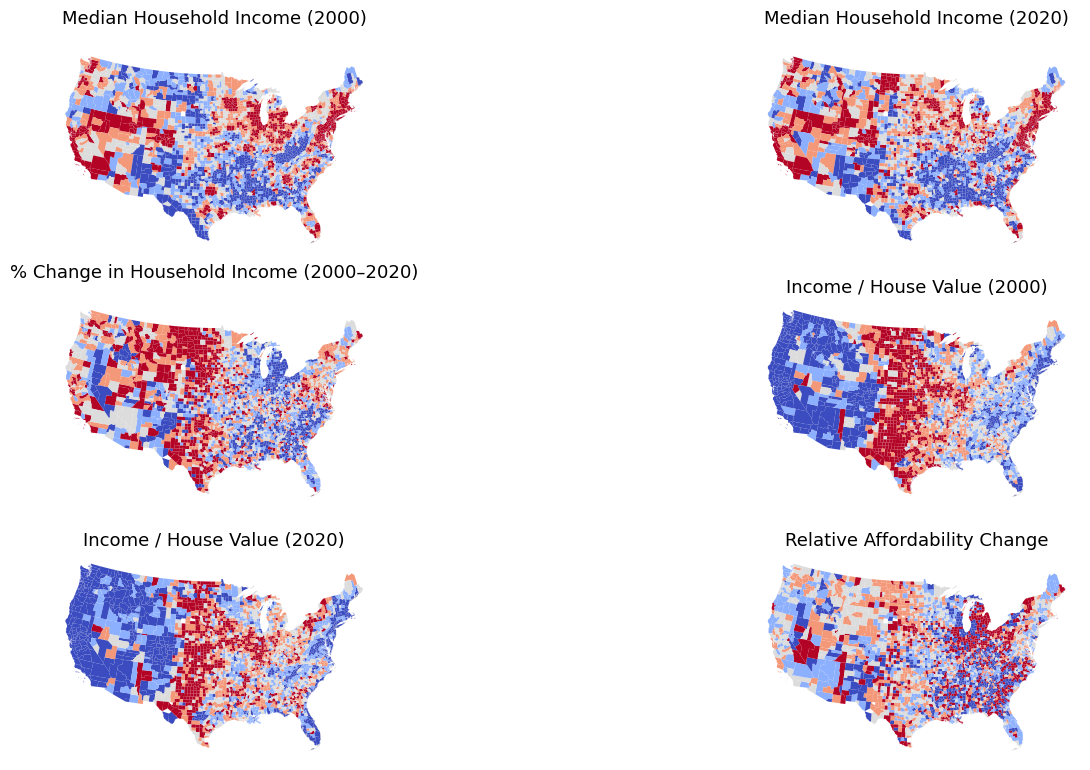

In [14]:
used_columns = ["MedianHouseholdIncome2000(adjusted)",
                "MedianHouseholdIncome2020",
                "%ChangeIncome",
                "income/value2000",
                "income/value2020",
                "%Income/%Value"]
titles = [
    'Median Household Income (2000)',
    'Median Household Income (2020)',
    '% Change in Household Income (2000–2020)',
    'Income / House Value (2000)',
    'Income / House Value (2020)',
    'Relative Affordability Change']
fig, axes = plt.subplots(3, 2, figsize=(18, 9), constrained_layout=True)
axes = axes.flatten()
for i, col in enumerate(used_columns):
    gdf_MedianHouseIndicator.plot(column=col,
             cmap='coolwarm',
              scheme = "quantiles" ,                   
#              linewidth=0.2,
#              edgecolor='black',
#              legend=True,
             ax=axes[i])
    axes[i].set_title(titles[i], fontsize=13)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Process of Amenity data

In [15]:
# TJan["FIPS"]  = TJan["FIPS"].astype(str).str.rjust(5,"0")
# TJuly["FIPS"] = TJuly["FIPS"].astype(str).str.rjust(5,"0")
# TJan_sel  = TJan[["FIPS","MEAN"]].rename(columns={"MEAN":"TJAN"})
# TJuly_sel = TJuly[["FIPS","MEAN"]].rename(columns={"MEAN":"TJULY"})
# T_sel = pd.merge(TJan_sel,TJuly_sel,on="FIPS")

In [16]:
Amenity["FIPS"]  = Amenity["FIPS"].astype(str).str.rjust(5,"0")
Amenity = Amenity[["FIPS","Scale","Level"]]
Amenity.head()

,FIPS,Scale,Level
0,01001,0.78,4
1,01003,1.82,4
2,01005,0.19,4
3,01007,-0.15,3
4,01009,0.23,4


### Process of Location Affordability Index (LAI)

In [17]:
HAI["FIPS"]  = HAI["FIPS"].astype(str).str.rjust(5,"0")
HAI = HAI.rename(columns={
    "Weight_HAI":"W_HT_HAI"
#     "MEAN_hh_type1_h":"W_HT_LAI"
})
HAI = HAI[["FIPS","W_HT_HAI"]]
non_conus_fips_prefixes = ['02', '15', '60', '66', '69', '72', '78']  # Alaska, Hawaii, and island territories
HAI = HAI[
    ~HAI['FIPS'].str[:2].isin(non_conus_fips_prefixes)
]

### Process of SHELDUS

In [18]:
SHELDUS['County FIPS'] = SHELDUS['County FIPS'].str.replace("'", "")
SHELDUS_0020 = SHELDUS[(SHELDUS["Year"]<2021) & (SHELDUS["Year"]>2000)]
SHELDUS_0020 = SHELDUS_0020[~((SHELDUS_0020['Year'] == 2000) & (SHELDUS_0020['Month'] <= 6))]
SHELDUS_0020 = SHELDUS_0020[~((SHELDUS_0020['Year'] == 2020) & (SHELDUS_0020['Month'] >= 7))]
SHELDUS_0020["StateID"] = SHELDUS_0020["County FIPS"].astype(str).str[:2]
SHELDUS_0020 = SHELDUS_0020[~SHELDUS_0020["StateID"].isin(non_conus_fips_prefixes)]
SHELDUS_0020_dis = SHELDUS_0020.groupby(["Hazard"]).agg({"PropertyDmg(ADJ 2020)":"sum","Fatalities":"sum","Injuries":"sum"}).reset_index()
SHELDUS_0020_dis.sort_values(by="PropertyDmg(ADJ 2020)",ascending=False)

,Hazard,PropertyDmg(ADJ 2020),Fatalities,Injuries
4,Flooding,2.056574e+11,1648.020,1387.000
8,Hurricane/Tropical Storm,1.759030e+11,1215.980,1300.010
12,Tornado,3.784049e+10,1504.000,19077.000
15,Wildfire,3.218132e+10,296.000,1619.960
6,Hail,2.999533e+10,3.000,620.000
16,Wind,1.825596e+10,973.315,3993.930
17,Winter Weather,1.136860e+10,648.995,2833.035
11,Severe Storm/Thunder Storm,5.431994e+09,303.500,2387.000
3,Earthquake,4.256910e+09,7.990,223.000
9,Landslide,3.151915e+09,183.960,300.010


In [19]:
SHELDUS_0020_sel = SHELDUS_0020[SHELDUS_0020["Hazard"].isin(['Flooding','Hurricane/Tropical Storm','Wildfire','Tornado'])].reset_index(drop=True)
SHELDUS_0020_sel_use = SHELDUS_0020_sel[['County FIPS', 'Hazard', 'Year',"Month",'PropertyDmg(ADJ 2020)','Fatalities','Injuries']]

def calculate_period(row):
    year = row['Year']
    month = row['Month']
    # If month is from July to December, the period is the current year
    if month >= 7:
        return year +1
    # If month is from January to June, the period is the previous year
    else:
        return year

# Apply the function to the dataframe
SHELDUS_0020_sel_use['Period'] = SHELDUS_0020_sel_use.apply(calculate_period, axis=1)
SHELDUS_0020_sel_use["Count"]  = 1
SHELDUS_0020_sel_use_group = SHELDUS_0020_sel_use.groupby(["County FIPS","Hazard","Period"]).agg({"PropertyDmg(ADJ 2020)":"sum",
                                                                                                 'Fatalities':"sum",
                                                                                                  'Injuries':"sum",
                                                                                                  "Count":"sum"}).reset_index()

C:\Users\xiang11\AppData\Local\Temp\ipykernel_10980\2092878197.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SHELDUS_0020_sel_use['Period'] = SHELDUS_0020_sel_use.apply(calculate_period, axis=1)
C:\Users\xiang11\AppData\Local\Temp\ipykernel_10980\2092878197.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SHELDUS_0020_sel_use["Count"]  = 1


In [20]:
disaster_list = ['Flooding','Hurricane/Tropical Storm','Wildfire','Tornado']
flood_temp = SHELDUS_0020_sel_use_group[SHELDUS_0020_sel_use_group["Hazard"]==disaster_list[0]]
flood_list = list(flood_temp["County FIPS"].unique())
hurricane_temp = SHELDUS_0020_sel_use_group[SHELDUS_0020_sel_use_group["Hazard"]==disaster_list[1]]
hurricane_list = list(hurricane_temp["County FIPS"].unique())
wildfire_temp = SHELDUS_0020_sel_use_group[SHELDUS_0020_sel_use_group["Hazard"]==disaster_list[2]]
wildfire_list = list(wildfire_temp["County FIPS"].unique())
tornado_temp = SHELDUS_0020_sel_use_group[SHELDUS_0020_sel_use_group["Hazard"]==disaster_list[3]]
tornado_list = list(tornado_temp["County FIPS"].unique())

# Panel Regression Analysis

### Create the panel dataframe

In [21]:
correct_pop_columns = ["FIPS","POPESTIMATE2000","POPESTIMATE2001","POPESTIMATE2002","POPESTIMATE2003","POPESTIMATE2004",
                       "POPESTIMATE2005","POPESTIMATE2006","POPESTIMATE2007","POPESTIMATE2008","POPESTIMATE2009",
                       "POPESTIMATE2010_x","POPESTIMATE2011","POPESTIMATE2012","POPESTIMATE2013","POPESTIMATE2014",
                       "POPESTIMATE2015","POPESTIMATE2016","POPESTIMATE2017","POPESTIMATE2018","POPESTIMATE2019","POPESTIMATE2020"]
correct_pop_columns_rev = ["FIPS","POP2000","POP2001","POP2002","POP2003","POP2004",
                       "POP2005","POP2006","POP2007","POP2008","POP2009",
                       "POP2010","POP2011","POP2012","POP2013","POP2014",
                       "POP2015","POP2016","POP2017","POP2018","POP2019","POP2020"]
df_pep_0120_pop_use = df_pep_0120[correct_pop_columns]
df_pep_0120_pop_use.columns = correct_pop_columns_rev

In [22]:
years = range(2000, 2021)
year_cols = [f'POP{year}' for year in years]
df2_long = pd.melt(df_pep_0120_pop_use, id_vars=['FIPS'], value_vars=year_cols, var_name='Year', value_name='Population')
df2_long['Year'] = df2_long['Year'].str.extract('(\d+)').astype(int)  # Convert Year to integer

# Merge the dataframes
SHELDUS_0020_sel_use_group['County FIPS'] = SHELDUS_0020_sel_use_group['County FIPS'].astype(str)  # Ensure FIPS codes are strings if they have leading zeros
SHELDUS_0020_sel_use_group['Year'] = SHELDUS_0020_sel_use_group['Period'].astype(int)  # Ensure Year is integer
# merged_df = pd.merge(SHELDUS_0020_sel_use_group, df2_long, left_on=['County FIPS', 'Year'], right_on=['FIPS', 'Year'], how='left')

# Result
# merged_df["PropertyDmgPerCapita"] = merged_df["PropertyDmg(ADJ 2020)"] / merged_df["Population"]

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\xiang11\AppData\Local\Temp\ipykernel_10980\2987025524.py:4: SyntaxWarning: invalid escape sequence '\d'
  df2_long['Year'] = df2_long['Year'].str.extract('(\d+)').astype(int)  # Convert Year to integer


In [23]:
disaster_list = ['Flooding', 'Hurricane/Tropical Storm', 'Tornado', 'Wildfire']
df_disaster_year = list()
for each in disaster_list:
    df_temp_used = SHELDUS_0020_sel_use_group[SHELDUS_0020_sel_use_group["Hazard"]==each]
    df_temp_used_merge = pd.merge(df2_long,df_temp_used,left_on=["FIPS","Year"],right_on=["County FIPS","Year"],how = "outer")
    df_temp_used_merge = df_temp_used_merge[["FIPS","Year","Population","PropertyDmg(ADJ 2020)","Fatalities","Injuries","Count"]]
    df_temp_used_merge["PropertyDmgPerCapita"] = df_temp_used_merge["PropertyDmg(ADJ 2020)"]/df_temp_used_merge["Population"]
    df_temp_used_merge["Existance"] = np.where(
    df_temp_used_merge['Count'] > 0,
    1,
    0
)
    df_temp_used_merge = df_temp_used_merge.fillna(0)
    df_disaster_year.append(df_temp_used_merge)

### Next step is to create the yearly panel data for each disaster

In [24]:
df_flood_year = df_disaster_year[0]
df_hurricane_year = df_disaster_year[1]
df_tornado_year = df_disaster_year[2]
df_wildfire_year = df_disaster_year[3]

In [25]:
df_flood_year     = df_flood_year[df_flood_year["FIPS"].isin(flood_list)].reset_index()
df_hurricane_year = df_hurricane_year[df_hurricane_year["FIPS"].isin(hurricane_list)].reset_index()
df_tornado_year   = df_tornado_year[df_tornado_year["FIPS"].isin(tornado_list)].reset_index()
df_wildfire_year  = df_wildfire_year[df_wildfire_year["FIPS"].isin(wildfire_list)].reset_index()

In [26]:
def calculate_disaster_existence_percentages(df, fips_col="FIPS", year_col="Year", exist_col="Existance"):
    df_sorted = df.sort_values(by=[fips_col, year_col]).copy()
    df_sorted["Existance_lag1"] = df_sorted.groupby(fips_col)[exist_col].shift(1)

    both = ((df_sorted[exist_col] == 1) & (df_sorted["Existance_lag1"] == 1)).sum()
    either = ((df_sorted[exist_col] == 1) | (df_sorted["Existance_lag1"] == 1)).sum()
    neither = ((df_sorted[exist_col] == 0) & (df_sorted["Existance_lag1"] == 0)).sum()
    total = len(df_sorted)

    return {
        "both_current_and_last_year": round(100 * both / total, 2),
        "either_current_or_last_year": round(100 * either / total, 2),
        "neither_current_nor_last_year": round(100 * neither / total, 2)
    }

In [27]:
calculate_disaster_existence_percentages(df_flood_year)

{'both_current_and_last_year': 13.51,
 'either_current_or_last_year': 44.16,
 'neither_current_nor_last_year': 51.08}

In [28]:
calculate_disaster_existence_percentages(df_hurricane_year)

{'both_current_and_last_year': 2.06,
 'either_current_or_last_year': 20.85,
 'neither_current_nor_last_year': 74.39}

In [29]:
calculate_disaster_existence_percentages(df_tornado_year)

{'both_current_and_last_year': 4.73,
 'either_current_or_last_year': 30.95,
 'neither_current_nor_last_year': 64.29}

In [30]:
calculate_disaster_existence_percentages(df_wildfire_year)

{'both_current_and_last_year': 2.73,
 'either_current_or_last_year': 18.28,
 'neither_current_nor_last_year': 76.96}

In [31]:
correct_netmig_columns = []
for year in range(2001, 2021):
    column_name_x = f'RNETMIG{year}_x'
    column_name_y = f'RNETMIG{year}_y'
    column_name = f'RNETMIG{year}'
    if column_name in df_pep_0120.columns:
        correct_netmig_columns.append(column_name)
    elif column_name_x in df_pep_0120.columns:
        correct_netmig_columns.append(column_name_x)
    elif column_name_y in df_pep_0120.columns:
        correct_netmig_columns.append(column_name_y)

In [32]:
correct_nmr_columns = ["FIPS","RNETMIG2001","RNETMIG2002","RNETMIG2003","RNETMIG2004",
                       "RNETMIG2005","RNETMIG2006","RNETMIG2007","RNETMIG2008","RNETMIG2009",
                       "RNETMIG2010","RNETMIG2011","RNETMIG2012","RNETMIG2013","RNETMIG2014",
                       "RNETMIG2015","RNETMIG2016","RNETMIG2017","RNETMIG2018","RNETMIG2019","RNETMIG2020"]
correct_nmr_columns_rev = ["FIPS","NMR2001","NMR2002","NMR2003","NMR2004",
                       "NMR2005","NMR2006","NMR2007","NMR2008","NMR2009",
                       "NMR2010","NMR2011","NMR2012","NMR2013","NMR2014",
                       "NMR2015","NMR2016","NMR2017","NMR2018","NMR2019","NMR2020"]

df_pep_0120_nmr_use = df_pep_0120[correct_nmr_columns]
df_pep_0120_nmr_use.columns = correct_nmr_columns_rev


In [33]:
years = range(2001, 2021)
year_cols = [f'NMR{year}' for year in years]
dfnmr_long = pd.melt(df_pep_0120_nmr_use, id_vars=['FIPS'], value_vars=year_cols, var_name='Year', value_name='NMR')
dfnmr_long['Year'] = dfnmr_long['Year'].str.extract('(\d+)').astype(int)

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\xiang11\AppData\Local\Temp\ipykernel_10980\910903619.py:4: SyntaxWarning: invalid escape sequence '\d'
  dfnmr_long['Year'] = dfnmr_long['Year'].str.extract('(\d+)').astype(int)


In [34]:
dfnmr_long.sort_values(by=['FIPS', 'Year'], inplace=True)

In [35]:
def add_log_transforms(df):
    df["log_count"] = np.log1p(df["Count"])
    df["log_injury"] = np.log1p(df["Injuries"])
    df["log_fatality"] = np.log1p(df["Fatalities"])
    df["log_damage"] = np.log1p(df["PropertyDmgPerCapita"])
    return df
def add_lagged_variables(df, group_col="FIPS"):
    to_lag = ["log_count", "log_injury", "log_fatality", "log_damage","Existance"]
    for var in to_lag:
        df[f"{var}_lag1"] = df.groupby(group_col)[var].shift(1)
    return df

In [36]:
# df_flood_year = add_dummy_variables(df_flood_year)
df_flood_year = add_log_transforms(df_flood_year)
df_flood_year = add_lagged_variables(df_flood_year)

In [37]:
# df_hurricane_year = add_dummy_variables(df_hurricane_year)
df_hurricane_year = add_log_transforms(df_hurricane_year)
df_hurricane_year = add_lagged_variables(df_hurricane_year)

In [38]:
# df_tornado_year = add_dummy_variables(df_tornado_year)
df_tornado_year = add_log_transforms(df_tornado_year)
df_tornado_year = add_lagged_variables(df_tornado_year)

In [39]:
# df_wildfire_year = add_dummy_variables(df_wildfire_year)
df_wildfire_year = add_log_transforms(df_wildfire_year)
df_wildfire_year = add_lagged_variables(df_wildfire_year)

In [40]:
df_year_nmr_flood     = pd.merge(dfnmr_long,df_flood_year,on=["FIPS",'Year'],how="inner")
df_year_nmr_hurricane = pd.merge(dfnmr_long,df_hurricane_year,on=["FIPS",'Year'],how="inner")
df_year_nmr_tornado   = pd.merge(dfnmr_long,df_tornado_year,on=["FIPS",'Year'],how="inner")
df_year_nmr_wildfire  = pd.merge(dfnmr_long,df_wildfire_year,on=["FIPS",'Year'],how="inner")

In [41]:
df_used = df_year_nmr_flood.set_index(["FIPS", "Year"])
used_vars = ["log_damage","log_damage_lag1",
             "log_fatality","log_fatality_lag1",
             "log_injury","log_injury_lag1",
             "log_count","log_count_lag1",
             "Existance","Existance_lag1"]
def run_panel_regression(df, exog_vars, name="Model"):
    # Drop rows with NaNs in any exog or endog
    model_df = df[exog_vars + ['NMR']].dropna()
    exog = model_df[exog_vars]
    endog = model_df['NMR']
    
    fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
    fe_result = fe_model.fit()

    print(f"\n📘 Fixed Effects Results – {name}")
    print(fe_result)

    return fe_result
exog_vars_current = used_vars 
fe_current = run_panel_regression(df_used, exog_vars_current, "Flood")


📘 Fixed Effects Results – Flood
                          PanelOLS Estimation Summary                           
Dep. Variable:                    NMR   R-squared:                        0.0018
Estimator:                   PanelOLS   R-squared (Between):              0.0036
No. Observations:               58740   R-squared (Within):               0.0016
Date:                Thu, May 08 2025   R-squared (Overall):              0.0023
Time:                        09:38:03   Log-likelihood                -2.291e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      9.8690
Entities:                        2937   P-value                           0.0000
Avg Obs:                       20.000   Distribution:                F(10,55774)
Min Obs:                       20.000                                           
Max Obs:                       20.000   F-statistic (robust):             9.

In [42]:
df_used = df_year_nmr_hurricane.set_index(["FIPS", "Year"])
used_vars = ["log_damage","log_damage_lag1",
             "log_fatality","log_fatality_lag1",
             "log_injury","log_injury_lag1",
             "log_count","log_count_lag1",
             "Existance","Existance_lag1"]
def run_panel_regression(df, exog_vars, name="Model"):
    # Drop rows with NaNs in any exog or endog
    model_df = df[exog_vars + ['NMR']].dropna()
    exog = model_df[exog_vars]
    endog = model_df['NMR']
    
    fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
    fe_result = fe_model.fit()

    print(f"\n📘 Fixed Effects Results – {name}")
    print(fe_result)

    return fe_result
exog_vars_current = used_vars 
fe_current = run_panel_regression(df_used, exog_vars_current, "Hurricane")


📘 Fixed Effects Results – Hurricane
                          PanelOLS Estimation Summary                           
Dep. Variable:                    NMR   R-squared:                        0.1991
Estimator:                   PanelOLS   R-squared (Between):             -0.0062
No. Observations:               16800   R-squared (Within):               0.1904
Date:                Thu, May 08 2025   R-squared (Overall):              0.1292
Time:                        09:38:03   Log-likelihood                -6.786e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      396.14
Entities:                         840   P-value                           0.0000
Avg Obs:                       20.000   Distribution:                F(10,15931)
Min Obs:                       20.000                                           
Max Obs:                       20.000   F-statistic (robust):           

In [43]:
df_used = df_year_nmr_tornado.set_index(["FIPS", "Year"])
used_vars = ["log_damage","log_damage_lag1",
             "log_fatality","log_fatality_lag1",
             "log_injury","log_injury_lag1",
             "log_count","log_count_lag1",
             "Existance","Existance_lag1"]
def run_panel_regression(df, exog_vars, name="Model"):
    # Drop rows with NaNs in any exog or endog
    model_df = df[exog_vars + ['NMR']].dropna()
    exog = model_df[exog_vars]
    endog = model_df['NMR']
    
    fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
    fe_result = fe_model.fit()

    print(f"\n📘 Fixed Effects Results – {name}")
    print(fe_result)

    return fe_result
exog_vars_current = used_vars 
fe_current = run_panel_regression(df_used, exog_vars_current, "Tornado")


📘 Fixed Effects Results – Tornado
                          PanelOLS Estimation Summary                           
Dep. Variable:                    NMR   R-squared:                        0.0003
Estimator:                   PanelOLS   R-squared (Between):             -0.0022
No. Observations:               50100   R-squared (Within):               0.0004
Date:                Thu, May 08 2025   R-squared (Overall):             -0.0005
Time:                        09:38:04   Log-likelihood                 -1.94e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      1.4114
Entities:                        2505   P-value                           0.1679
Avg Obs:                       20.000   Distribution:                F(10,47566)
Min Obs:                       20.000                                           
Max Obs:                       20.000   F-statistic (robust):             

In [44]:
df_used = df_year_nmr_wildfire.set_index(["FIPS", "Year"])
used_vars = ["log_damage","log_damage_lag1",
             "log_fatality","log_fatality_lag1",
             "log_injury","log_injury_lag1",
             "log_count","log_count_lag1",
             "Existance","Existance_lag1"]
def run_panel_regression(df, exog_vars, name="Model"):
    # Drop rows with NaNs in any exog or endog
    model_df = df[exog_vars + ['NMR']].dropna()
    exog = model_df[exog_vars]
    endog = model_df['NMR']
    
    fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
    fe_result = fe_model.fit()

    print(f"\n📘 Fixed Effects Results – {name}")
    print(fe_result)

    return fe_result
exog_vars_current = used_vars 
fe_current = run_panel_regression(df_used, exog_vars_current, "Wildfire")


📘 Fixed Effects Results – Wildfire
                          PanelOLS Estimation Summary                           
Dep. Variable:                    NMR   R-squared:                        0.0012
Estimator:                   PanelOLS   R-squared (Between):             -0.0112
No. Observations:               13220   R-squared (Within):               0.0017
Date:                Thu, May 08 2025   R-squared (Overall):             -0.0035
Time:                        09:38:04   Log-likelihood                -5.102e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      1.5370
Entities:                         661   P-value                           0.1193
Avg Obs:                       20.000   Distribution:                F(10,12530)
Min Obs:                       20.000                                           
Max Obs:                       20.000   F-statistic (robust):            

## Preprocessing for Time Series Analysis, XGBOOST, and regression analysis

In [45]:
SHELDUS_0020_hurricane = SHELDUS_0020_sel[SHELDUS_0020_sel["Hazard"]=="Hurricane/Tropical Storm"].reset_index()
SHELDUS_0020_flooding  = SHELDUS_0020_sel[SHELDUS_0020_sel["Hazard"]=="Flooding"].reset_index()

In [46]:
hurricane_induced_floods = pd.merge(
    SHELDUS_0020_flooding, 
    SHELDUS_0020_hurricane, 
    on=['County FIPS', 'Year', 'Month'],
    suffixes=('_flood', '_hurricane')
)
flood_indices = hurricane_induced_floods['index_flood']

In [47]:
SHELDUS_0020_sel.loc[flood_indices, 'Hazard'] = 'Hurricane/Tropical Storm'

In [48]:
SHELDUS_0020_use = SHELDUS_0020_sel[(SHELDUS_0020_sel["Fatalities"]!=0)|(SHELDUS_0020_sel["Injuries"]!=0)|(SHELDUS_0020_sel["PropertyDmgPerCapita(ADJ 2020)"]>1)]
def calculate_period(row):
    year = row['Year']
    month = row['Month']
    # If month is from July to December, the period is the current year
    if month >= 7:
        return year +1
    # If month is from January to June, the period is the previous year
    else:
        return year

# Apply the function to the dataframe
SHELDUS_0020_use['Period'] = SHELDUS_0020_use.apply(calculate_period, axis=1)
SHELDUS_0020_use["Year"] = SHELDUS_0020_use["Period"]
SHELDUS_0020_use_group = SHELDUS_0020_use.groupby(["County FIPS","Hazard","Year"]).agg({"Month":"count",
                                                                                        "Fatalities":"sum",
                                                                                        "Injuries":"sum",
                                                                                        "PropertyDmg(ADJ 2020)":"sum",
                                                                                        
                                                                                        
                                                                                        "PropertyDmgPerCapita(ADJ 2020)":"mean",
                                                                                       "CropDmg(ADJ 2020)":"sum",
                                                                                       "CropDmgPerCapita(ADJ 2020)":"mean"}).reset_index()
SHELDUS_0020_use_group = SHELDUS_0020_use_group.rename(columns={"Month":"count"})

# SHELDUS_0020_use_group["Loss"] = SHELDUS_0020_use_group["Fatalities"] * 11600000 + SHELDUS_0020_use_group["Injuries"] / 10 * 11600000 + SHELDUS_0020_use_group["PropertyDmg(ADJ 2020)"]

df_20_years_by_county = SHELDUS_0020_use_group.groupby(['County FIPS',"Hazard"]).agg({"count":"sum",
                                                                                        "Fatalities":"sum",
                                                                                        "Injuries":"sum",
                                                                                        "PropertyDmg(ADJ 2020)":"sum",
                                                                                        "PropertyDmgPerCapita(ADJ 2020)":"mean",
                                                                                        "CropDmg(ADJ 2020)":"sum",
                                                                                        "CropDmgPerCapita(ADJ 2020)":"mean"
                                                                                        }).reset_index()


C:\Users\xiang11\AppData\Local\Temp\ipykernel_10980\2773851128.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SHELDUS_0020_use['Period'] = SHELDUS_0020_use.apply(calculate_period, axis=1)
C:\Users\xiang11\AppData\Local\Temp\ipykernel_10980\2773851128.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SHELDUS_0020_use["Year"] = SHELDUS_0020_use["Period"]


In [49]:
df_20_years_by_county = df_20_years_by_county.rename(columns={"count":"frequency"})

In [50]:
def classify_impact(data, value_column):
    Q1 = data[value_column].quantile(0.25)
    Q3 = data[value_column].quantile(0.75)
    
    def classification(value):
        if value <= Q1:
            return 'Low Impact'
        elif (value > Q1) & (value < Q3):
            return 'Moderate Impact'
        elif value >= Q3:
            return 'High Impact'
    
    return data[value_column].apply(classification)

In [51]:
def classify_combined_impact(data, column1, column2, new_column):
    def determine_impact(impact1, impact2):
        if impact1 == 'High Impact' and impact2 == 'High Impact':
            return 'High Impact'
        elif impact1 == 'Low Impact' and impact2 == 'Low Impact':
            return 'Low Impact'
        else:
            return 'Moderate Impact'

    data[new_column] = data.apply(lambda row: determine_impact(row[column1], row[column2]), axis=1)
    return data

In [52]:
disaster_list = ['Flooding','Hurricane/Tropical Storm','Wildfire','Tornado']
SHELDUS_20_use_flooding  = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Flooding"]
SHELDUS_20_use_hurricane = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Hurricane/Tropical Storm"]
SHELDUS_20_use_wildfire  = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Wildfire"]
# SHELDUS_20_use_heat      = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Heat"]
SHELDUS_20_use_tornado   = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Tornado"]


SHELDUS_20_use_flooding['ImpactLevel_1'] = classify_impact(SHELDUS_20_use_flooding, "PropertyDmgPerCapita(ADJ 2020)")
SHELDUS_20_use_hurricane['ImpactLevel_1'] = classify_impact(SHELDUS_20_use_hurricane, "PropertyDmgPerCapita(ADJ 2020)")
SHELDUS_20_use_wildfire['ImpactLevel_1'] = classify_impact(SHELDUS_20_use_wildfire, "PropertyDmgPerCapita(ADJ 2020)")
# SHELDUS_20_use_heat['ImpactLevel_1'] = classify_impact(SHELDUS_20_use_heat, "Loss")
SHELDUS_20_use_tornado['ImpactLevel_1'] = classify_impact(SHELDUS_20_use_tornado, "PropertyDmgPerCapita(ADJ 2020)")

SHELDUS_20_use_flooding['ImpactLevel_2'] = classify_impact(SHELDUS_20_use_flooding, "frequency")
SHELDUS_20_use_hurricane['ImpactLevel_2'] = classify_impact(SHELDUS_20_use_hurricane,"frequency")
SHELDUS_20_use_wildfire['ImpactLevel_2'] = classify_impact(SHELDUS_20_use_wildfire, "frequency")
# SHELDUS_20_use_heat['ImpactLevel_2'] = classify_impact(SHELDUS_20_use_heat, "frequency")
SHELDUS_20_use_tornado['ImpactLevel_2'] = classify_impact(SHELDUS_20_use_tornado, "frequency")

SHELDUS_20_use_flooding = classify_combined_impact(SHELDUS_20_use_flooding, 'ImpactLevel_1', 'ImpactLevel_2', 'ImpactLevel')
SHELDUS_20_use_hurricane = classify_combined_impact(SHELDUS_20_use_hurricane, 'ImpactLevel_1', 'ImpactLevel_2', 'ImpactLevel')
SHELDUS_20_use_wildfire = classify_combined_impact(SHELDUS_20_use_wildfire, 'ImpactLevel_1', 'ImpactLevel_2', 'ImpactLevel')
# SHELDUS_20_use_heat = classify_combined_impact(SHELDUS_20_use_heat, 'ImpactLevel_1', 'ImpactLevel_2', 'ImpactLevel')
SHELDUS_20_use_tornado = classify_combined_impact(SHELDUS_20_use_tornado, 'ImpactLevel_1', 'ImpactLevel_2', 'ImpactLevel')

C:\Users\xiang11\AppData\Local\Temp\ipykernel_10980\4100627513.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SHELDUS_20_use_flooding['ImpactLevel_1'] = classify_impact(SHELDUS_20_use_flooding, "PropertyDmgPerCapita(ADJ 2020)")
C:\Users\xiang11\AppData\Local\Temp\ipykernel_10980\4100627513.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SHELDUS_20_use_hurricane['ImpactLevel_1'] = classify_impact(SHELDUS_20_use_hurricane, "PropertyDmgPerCapita(ADJ 2020)")
C:\Users\xiang11\AppData\Local\Temp\ipykern

In [53]:
correct_netmig_columns = []
for year in range(2001, 2021):
    column_name_x = f'RNETMIG{year}_x'
    column_name_y = f'RNETMIG{year}_y'
    column_name = f'RNETMIG{year}'
    if column_name in df_pep_0120.columns:
        correct_netmig_columns.append(column_name)
    elif column_name_x in df_pep_0120.columns:
        correct_netmig_columns.append(column_name_x)
    elif column_name_y in df_pep_0120.columns:
        correct_netmig_columns.append(column_name_y)

In [54]:
flooding_list = list(SHELDUS_20_use_flooding["County FIPS"])
flooding_high_list = list(SHELDUS_20_use_flooding[SHELDUS_20_use_flooding["ImpactLevel"] == "High Impact"]["County FIPS"])
flooding_low_list = list(SHELDUS_20_use_flooding[SHELDUS_20_use_flooding["ImpactLevel"] == "Low Impact"]["County FIPS"])
flooding_med_list = list(SHELDUS_20_use_flooding[SHELDUS_20_use_flooding["ImpactLevel"] == "Moderate Impact"]["County FIPS"])

hurricane_list = list(SHELDUS_20_use_hurricane["County FIPS"])
hurricane_high_list = list(SHELDUS_20_use_hurricane[SHELDUS_20_use_hurricane["ImpactLevel"] == "High Impact"]["County FIPS"])
hurricane_low_list = list(SHELDUS_20_use_hurricane[SHELDUS_20_use_hurricane["ImpactLevel"] == "Low Impact"]["County FIPS"])
hurricane_med_list = list(SHELDUS_20_use_hurricane[SHELDUS_20_use_hurricane["ImpactLevel"] == "Moderate Impact"]["County FIPS"])

wildfire_list = list(SHELDUS_20_use_wildfire["County FIPS"])
wildfire_high_list = list(SHELDUS_20_use_wildfire[SHELDUS_20_use_wildfire["ImpactLevel"] == "High Impact"]["County FIPS"])
wildfire_low_list = list(SHELDUS_20_use_wildfire[SHELDUS_20_use_wildfire["ImpactLevel"] == "Low Impact"]["County FIPS"])
wildfire_med_list = list(SHELDUS_20_use_wildfire[SHELDUS_20_use_wildfire["ImpactLevel"] == "Moderate Impact"]["County FIPS"])

# heat_list = list(SHELDUS_20_use_heat["County FIPS"])
# heat_high_list = list(SHELDUS_20_use_heat[SHELDUS_20_use_heat["ImpactLevel"] == "High Impact"]["County FIPS"])
# heat_low_list = list(SHELDUS_20_use_heat[SHELDUS_20_use_heat["ImpactLevel"] == "Low Impact"]["County FIPS"])
# heat_med_list = list(SHELDUS_20_use_heat[SHELDUS_20_use_heat["ImpactLevel"] == "Moderate Impact"]["County FIPS"])

tornado_list = list(SHELDUS_20_use_tornado["County FIPS"])
tornado_high_list = list(SHELDUS_20_use_tornado[SHELDUS_20_use_tornado["ImpactLevel"] == "High Impact"]["County FIPS"])
tornado_low_list = list(SHELDUS_20_use_tornado[SHELDUS_20_use_tornado["ImpactLevel"] == "Low Impact"]["County FIPS"])
tornado_med_list = list(SHELDUS_20_use_tornado[SHELDUS_20_use_tornado["ImpactLevel"] == "Moderate Impact"]["County FIPS"])

In [55]:
yearly_flooding_all      = df_pep_0120[df_pep_0120["FIPS"].isin(flooding_list)]
yearly_flooding_all_mean = yearly_flooding_all[correct_netmig_columns].mean()
yearly_flooding_high     = df_pep_0120[df_pep_0120["FIPS"].isin(flooding_high_list)] 
yearly_flooding_high_mean= yearly_flooding_high[correct_netmig_columns].mean()
yearly_flooding_low      = df_pep_0120[df_pep_0120["FIPS"].isin(flooding_low_list)] 
yearly_flooding_low_mean = yearly_flooding_low[correct_netmig_columns].mean()
yearly_flooding_med      = df_pep_0120[df_pep_0120["FIPS"].isin(flooding_med_list)] 
yearly_flooding_med_mean = yearly_flooding_med[correct_netmig_columns].mean()

yearly_hurricane_all      = df_pep_0120[df_pep_0120["FIPS"].isin(hurricane_list)]
yearly_hurricane_all_mean = yearly_hurricane_all[correct_netmig_columns].mean()
yearly_hurricane_high     = df_pep_0120[df_pep_0120["FIPS"].isin(hurricane_high_list)] 
yearly_hurricane_high_mean= yearly_hurricane_high[correct_netmig_columns].mean()
yearly_hurricane_low      = df_pep_0120[df_pep_0120["FIPS"].isin(hurricane_low_list)] 
yearly_hurricane_low_mean = yearly_hurricane_low[correct_netmig_columns].mean()
yearly_hurricane_med      = df_pep_0120[df_pep_0120["FIPS"].isin(hurricane_med_list)] 
yearly_hurricane_med_mean = yearly_hurricane_med[correct_netmig_columns].mean()

yearly_wildfire_all      = df_pep_0120[df_pep_0120["FIPS"].isin(wildfire_list)]
yearly_wildfire_all_mean = yearly_wildfire_all[correct_netmig_columns].mean()
yearly_wildfire_high     = df_pep_0120[df_pep_0120["FIPS"].isin(wildfire_high_list)] 
yearly_wildfire_high_mean= yearly_wildfire_high[correct_netmig_columns].mean()
yearly_wildfire_low      = df_pep_0120[df_pep_0120["FIPS"].isin(wildfire_low_list)] 
yearly_wildfire_low_mean = yearly_wildfire_low[correct_netmig_columns].mean()
yearly_wildfire_med      = df_pep_0120[df_pep_0120["FIPS"].isin(wildfire_med_list)] 
yearly_wildfire_med_mean = yearly_wildfire_med[correct_netmig_columns].mean()

# yearly_heat_all      = df_pep_0120[df_pep_0120["FIPS"].isin(heat_list)]
# yearly_heat_all_mean = yearly_heat_all[correct_netmig_columns].mean()
# yearly_heat_high     = df_pep_0120[df_pep_0120["FIPS"].isin(heat_high_list)] 
# yearly_heat_high_mean= yearly_heat_high[correct_netmig_columns].mean()
# yearly_heat_low      = df_pep_0120[df_pep_0120["FIPS"].isin(heat_low_list)] 
# yearly_heat_low_mean = yearly_heat_low[correct_netmig_columns].mean()
# yearly_heat_med      = df_pep_0120[df_pep_0120["FIPS"].isin(heat_med_list)] 
# yearly_heat_med_mean = yearly_heat_med[correct_netmig_columns].mean()

yearly_tornado_all      = df_pep_0120[df_pep_0120["FIPS"].isin(tornado_list)]
yearly_tornado_all_mean = yearly_tornado_all[correct_netmig_columns].mean()
yearly_tornado_high     = df_pep_0120[df_pep_0120["FIPS"].isin(tornado_high_list)] 
yearly_tornado_high_mean= yearly_tornado_high[correct_netmig_columns].mean()
yearly_tornado_low      = df_pep_0120[df_pep_0120["FIPS"].isin(tornado_low_list)] 
yearly_tornado_low_mean = yearly_tornado_low[correct_netmig_columns].mean()
yearly_tornado_med      = df_pep_0120[df_pep_0120["FIPS"].isin(tornado_med_list)] 
yearly_tornado_med_mean = yearly_tornado_med[correct_netmig_columns].mean()

In [56]:
disaster_list = ['Flooding','Hurricane/Tropical Storm','Wildfire','Tornado']
Year_list = []
Disaster_list= []
for each in disaster_list:
    df_disaster_year_temp = SHELDUS_0020_use_group[SHELDUS_0020_use_group["Hazard"]==each]
    df_disaster_year_temp = df_disaster_year_temp.groupby("Year").sum("PropertyDmg(ADJ 2020)").reset_index()
    df_disaster_year_temp.sort_values("Year")
    Year_list.append(df_disaster_year_temp.Year.unique())
    Disaster_list.append(df_disaster_year_temp["PropertyDmg(ADJ 2020)"].unique())

In [57]:
flood_dmg_list = Disaster_list[0]
log_flood_dmg = np.log10(flood_dmg_list)
hurricane_dmg_list = Disaster_list[1]
log_hurricane_dmg = np.log10(hurricane_dmg_list)
wildfire_dmg_list = Disaster_list[2]
log_wildfire_dmg = np.log10(wildfire_dmg_list)
tornado_dmg_list = Disaster_list[3]
log_tornado_dmg = np.log10(tornado_dmg_list)

## Time Series Analysis Result

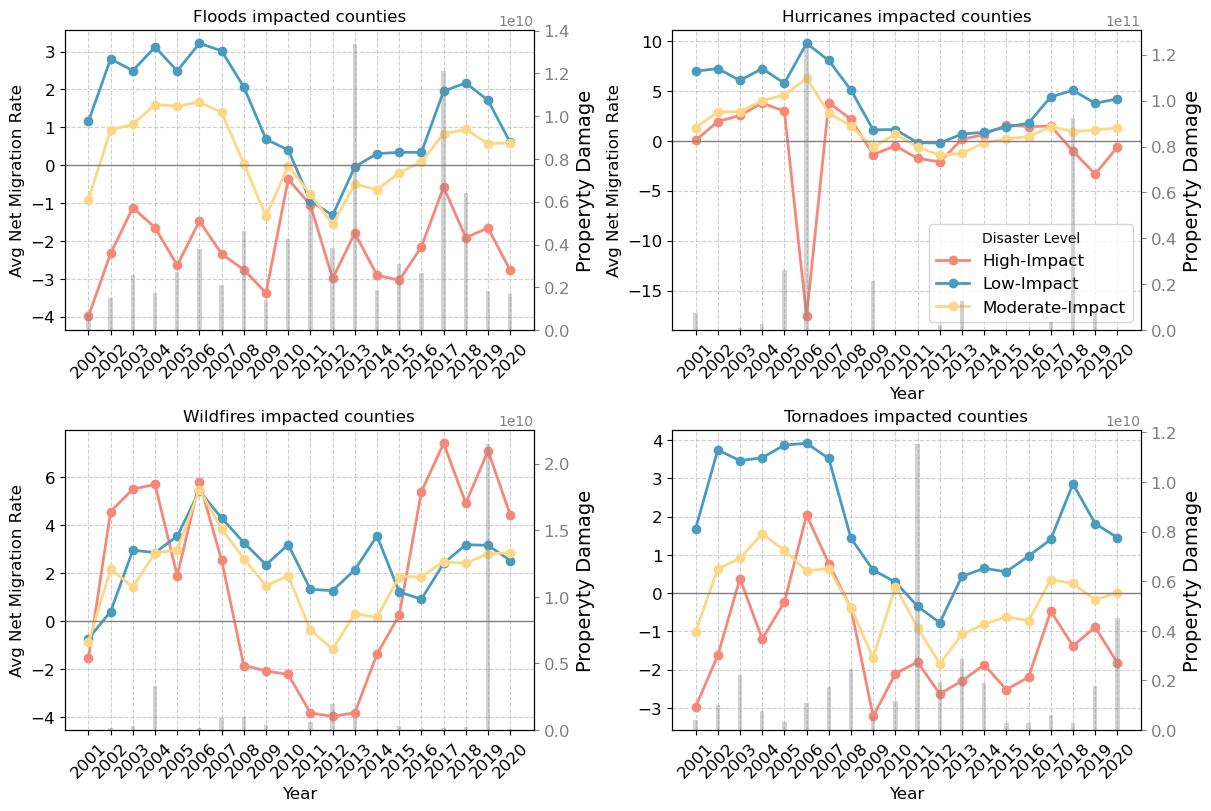

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.flatten()
years = list(range(2001, 2021))
fontsize = 12  # Slightly larger font for better readability
bar_x = 2020
bar_width = 0.2
# Improved color palette for visual distinction
colors = ['#499BC0', '#FDD786', '#F78779']

# Plotting data for floods
axes[0].plot(years, yearly_flooding_high_mean.values, marker='o', linestyle='-', color=colors[2], label='High', linewidth=2)
axes[0].plot(years, yearly_flooding_low_mean.values, marker='o', linestyle='-', color=colors[0], label='Low', linewidth=2)
axes[0].plot(years, yearly_flooding_med_mean.values, marker='o', linestyle='-', color=colors[1], label='Medium', linewidth=2)
ax1 = axes[0]
ax2 = ax1.twinx()
ax2.bar(Year_list[0], flood_dmg_list, width=bar_width, color="grey", alpha=0.35)
ax2.set_ylabel("Properyty Damage", fontsize=14)
ax2.tick_params(axis='y', labelsize=12, colors='gray')
axes[0].set_title("Floods impacted counties", fontsize=fontsize)
# axes[0].set_xlabel("Year", fontsize=fontsize)
axes[0].set_ylabel("Avg Net Migration Rate", fontsize=fontsize)
axes[0].set_xticks(years)
axes[0].set_xticklabels(years, rotation=45, fontsize=fontsize)
axes[0].tick_params(axis='y', labelsize=fontsize)
# axes[0].legend(title="Disaster Level", fontsize=fontsize)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].axhline(0, color='gray', linewidth=1)

# Plotting data for hurricanes
axes[1].plot(years, yearly_hurricane_high_mean.values, marker='o', linestyle='-', color=colors[2], label='High-Impact', linewidth=2)
axes[1].plot(years, yearly_hurricane_low_mean.values, marker='o', linestyle='-', color=colors[0], label='Low-Impact', linewidth=2)
axes[1].plot(years, yearly_hurricane_med_mean.values, marker='o', linestyle='-', color=colors[1], label='Moderate-Impact', linewidth=2)
ax1 = axes[1]
ax2 = ax1.twinx()
ax2.bar(Year_list[1], hurricane_dmg_list, width=bar_width, color="grey", alpha=0.35)
ax2.set_ylabel("Properyty Damage", fontsize=14)
ax2.tick_params(axis='y', labelsize=12, colors='gray')
axes[1].set_title("Hurricanes impacted counties", fontsize=fontsize)
axes[1].set_xlabel("Year", fontsize=fontsize)
axes[1].set_ylabel("Avg Net Migration Rate", fontsize=fontsize)
axes[1].set_xticks(years)
axes[1].set_xticklabels(years, rotation=45, fontsize=fontsize)
axes[1].legend(title="Disaster Level",fontsize=fontsize,loc='best')
axes[1].tick_params(axis='y', labelsize=fontsize)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].axhline(0, color='gray', linewidth=1)

# Plotting data for wildfires
axes[2].plot(years, yearly_wildfire_high_mean.values, marker='o', linestyle='-', color=colors[2], label='High', linewidth=2)
axes[2].plot(years, yearly_wildfire_low_mean.values, marker='o', linestyle='-', color=colors[0], label='Low', linewidth=2)
axes[2].plot(years, yearly_wildfire_med_mean.values, marker='o', linestyle='-', color=colors[1], label='Medium', linewidth=2)
ax1 = axes[2]
ax2 = ax1.twinx()
ax2.bar(Year_list[2], wildfire_dmg_list, width=bar_width, color="grey", alpha=0.35)
ax2.set_ylabel("Properyty Damage", fontsize=14)
ax2.tick_params(axis='y', labelsize=12, colors='gray')
axes[2].set_title("Wildfires impacted counties", fontsize=fontsize)
axes[2].set_xlabel("Year", fontsize=fontsize)
axes[2].set_ylabel("Avg Net Migration Rate", fontsize=fontsize)
axes[2].set_xticks(years)
axes[2].set_xticklabels(years, rotation=45, fontsize=fontsize)
axes[2].tick_params(axis='y', labelsize=fontsize)
# axes[2].legend(title="Disaster Level", fontsize=fontsize)
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].axhline(0, color='gray', linewidth=1)

# Plotting data for tornadoes
axes[3].plot(years, yearly_tornado_high_mean.values, marker='o', linestyle='-', color=colors[2], label='High', linewidth=2)
axes[3].plot(years, yearly_tornado_low_mean.values, marker='o', linestyle='-', color=colors[0], label='Low', linewidth=2)
axes[3].plot(years, yearly_tornado_med_mean.values, marker='o', linestyle='-', color=colors[1], label='Medium', linewidth=2)
ax1 = axes[3]
ax2 = ax1.twinx()
ax2.bar(Year_list[3], tornado_dmg_list, width=bar_width, color="grey", alpha=0.35)
ax2.set_ylabel("Properyty Damage", fontsize=14)
ax2.tick_params(axis='y', labelsize=12, colors='gray')
axes[3].set_title("Tornadoes impacted counties", fontsize=fontsize)
axes[3].set_xlabel("Year", fontsize=fontsize)
# axes[3].set_ylabel("Avg Net Migration Rate", fontsize=fontsize)
axes[3].set_xticks(years)
axes[3].set_xticklabels(years, rotation=45, fontsize=fontsize)
axes[3].tick_params(axis='y', labelsize=fontsize)
# axes[3].legend(title="Disaster Level", fontsize=fontsize)
axes[3].grid(True, linestyle='--', alpha=0.6)
axes[3].axhline(0, color='gray', linewidth=1)

# fig.savefig(r"F:\LongMig2025\results\maps\plot2\NMR_0402.png", dpi=300, bbox_inches="tight")


In [59]:
Floods = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Flooding"]
Floods = Floods.rename(columns={"frequency":"Flood_Frequency","PropertyDmgPerCapita(ADJ 2020)":"Flood_Loss","Fatalities":"Flood_Fatalities","Injuries":"Flood_Injuries"})
Hurricane = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Hurricane/Tropical Storm"]
Hurricane = Hurricane.rename(columns={"frequency":"Hurricane_Frequency","PropertyDmgPerCapita(ADJ 2020)":"Hurricane_Loss","Fatalities":"Hurricane_Fatalities","Injuries":"Hurricane_Injuries"})
Wildfire = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Wildfire"]
Wildfire = Wildfire.rename(columns={"frequency":"Wildfire_Frequency","PropertyDmgPerCapita(ADJ 2020)":"Wildfire_Loss","Fatalities":"Wildfire_Fatalities","Injuries":"Wildfire_Injuries"})
Tornado = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Tornado"]
Tornado = Tornado.rename(columns={"frequency":"Tornado_Frequency","PropertyDmgPerCapita(ADJ 2020)":"Tornado_Loss","Fatalities":"Tornado_Fatalities","Injuries":"Tornado_Injuries"})
# Heat = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Heat"]
# Heat = Heat.rename(columns={"frequency":"Heat_Frequency","PropertyDmgPerCapita(ADJ 2020)":"Heat_Loss","Fatalities":"Heat_Fatalities","Injuries":"Heat_Injuries"})
Floods["Flood_Occur"] = 1
Hurricane["Hurricane_Occur"] = 1
Wildfire["Wildfire_Occur"] = 1
Tornado["Tornado_Occur"] = 1
# Heat["Heat_Occur"] = 1
Floods = Floods[["County FIPS","Flood_Frequency","Flood_Loss","Flood_Occur","Flood_Fatalities","Flood_Injuries"]]
Hurricane = Hurricane[["County FIPS","Hurricane_Frequency","Hurricane_Loss","Hurricane_Occur","Hurricane_Fatalities","Hurricane_Injuries"]]
Wildfire = Wildfire[["County FIPS","Wildfire_Frequency","Wildfire_Loss","Wildfire_Occur","Wildfire_Fatalities","Wildfire_Injuries"]]
Tornado = Tornado[["County FIPS","Tornado_Frequency","Tornado_Loss","Tornado_Occur","Tornado_Fatalities","Tornado_Injuries"]]
# Heat = Heat[["County FIPS","Heat_Frequency","Heat_Loss","Heat_Occur","Heat_Fatalities","Heat_Injuries"]]

In [60]:
Disaster = pd.merge(Floods,Hurricane,on="County FIPS",how='outer')
Disaster = pd.merge(Disaster,Wildfire,on="County FIPS",how='outer')
Disaster = pd.merge(Disaster,Tornado,on="County FIPS",how='outer')
# Disaster = pd.merge(Disaster,Heat,on="County FIPS",how='outer')
Disaster = Disaster.fillna(0)
Disaster["FIPS"] = Disaster["County FIPS"].astype(str).str.rjust(5,"0")

In [61]:
Disaster.head()

,County FIPS,Flood_Frequency,Flood_Loss,Flood_Occur,Flood_Fatalities,Flood_Injuries,Hurricane_Frequency,Hurricane_Loss,Hurricane_Occur,Hurricane_Fatalities,...,Wildfire_Loss,Wildfire_Occur,Wildfire_Fatalities,Wildfire_Injuries,Tornado_Frequency,Tornado_Loss,Tornado_Occur,Tornado_Fatalities,Tornado_Injuries,FIPS
0,01001,5.0,8.460414,1.0,0.0,0.0,2.0,3.644830,1.0,0.0,...,0.0,0.0,0.0,0.0,7.0,49.856793,1.0,3.0,57.0,01001
1,01003,6.0,18.341990,1.0,2.0,1.0,4.0,18.590288,1.0,0.0,...,0.0,0.0,0.0,0.0,5.0,2.931754,1.0,0.0,7.0,01003
2,01005,2.0,1.249390,1.0,0.0,0.0,2.0,1.754460,1.0,0.0,...,0.0,0.0,0.0,0.0,6.0,5.448765,1.0,0.0,4.0,01005
3,01007,1.0,9.961340,1.0,0.0,0.0,2.0,8.162715,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,736.519440,1.0,1.0,10.0,01007
4,01009,2.0,2.889540,1.0,0.0,0.0,1.0,1.463220,1.0,0.0,...,0.0,0.0,0.0,0.0,8.0,74.229791,1.0,0.0,40.0,01009


### Compute Net Migration Rate (NMR)

In [62]:
correct_netmig_columns = []
for year in range(2001, 2021):
    column_name_x = f'RNETMIG{year}_x'
    column_name_y = f'RNETMIG{year}_y'
    column_name = f'RNETMIG{year}'
    if column_name in df_pep_0120.columns:
        correct_netmig_columns.append(column_name)
    elif column_name_x in df_pep_0120.columns:
        correct_netmig_columns.append(column_name_x)
    elif column_name_y in df_pep_0120.columns:
        correct_netmig_columns.append(column_name_y)

In [63]:
df_pep_0120["NetMigrationRateTotal"] = df_pep_0120[correct_netmig_columns].mean(axis=1)
df_pep_0120_used = df_pep_0120[['FIPS','STNAME_x', 'CTYNAME_x', 'NetMigrationRateTotal']]

In [64]:
# df_pep_0120.to_csv(data_path+"pep.csv")

In [65]:
df_NMR = pd.merge(df_pep_0120_used,county,on="FIPS",how="inner")
gdf_NMR = gpd.GeoDataFrame(df_NMR,geometry="geometry")

## NMR Map

<Figure size 1000x800 with 0 Axes>

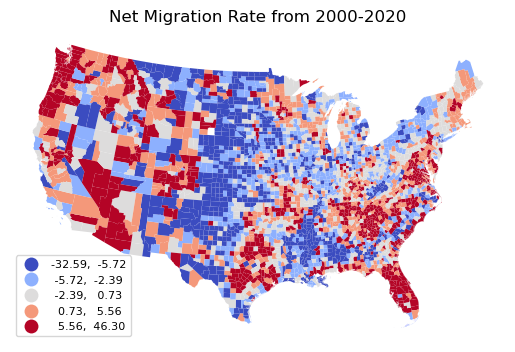

In [66]:
plt.figure(figsize=(10, 8))
gdf_NMR.plot(column="NetMigrationRateTotal",cmap="coolwarm",
             scheme="quantiles",
#              scheme='userdefined',classification_kwds={'bins':[-500,-100,-50,-25,-10,-0.1,0,0.1,10,25,50,100,500]},
             legend=True,legend_kwds={
        "fontsize": 8,  # Adjust font size for smaller text
        "loc": "lower left",  # Position the legend
    })
plt.title("Net Migration Rate from 2000-2020")
plt.axis('off')
plt.show()

## Disaster Map
### Map the frequency and loss

In [67]:
df_disaster = pd.merge(df_20_years_by_county,county,left_on="County FIPS",right_on="FIPS",how="inner")
gdf_disaster = gpd.GeoDataFrame(df_disaster,geometry="geometry")

C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\mapclassify\classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 4.
  self.bins = quantile(y, k=k)
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\mapclassify\classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 4.
  self.bins = quantile(y, k=k)


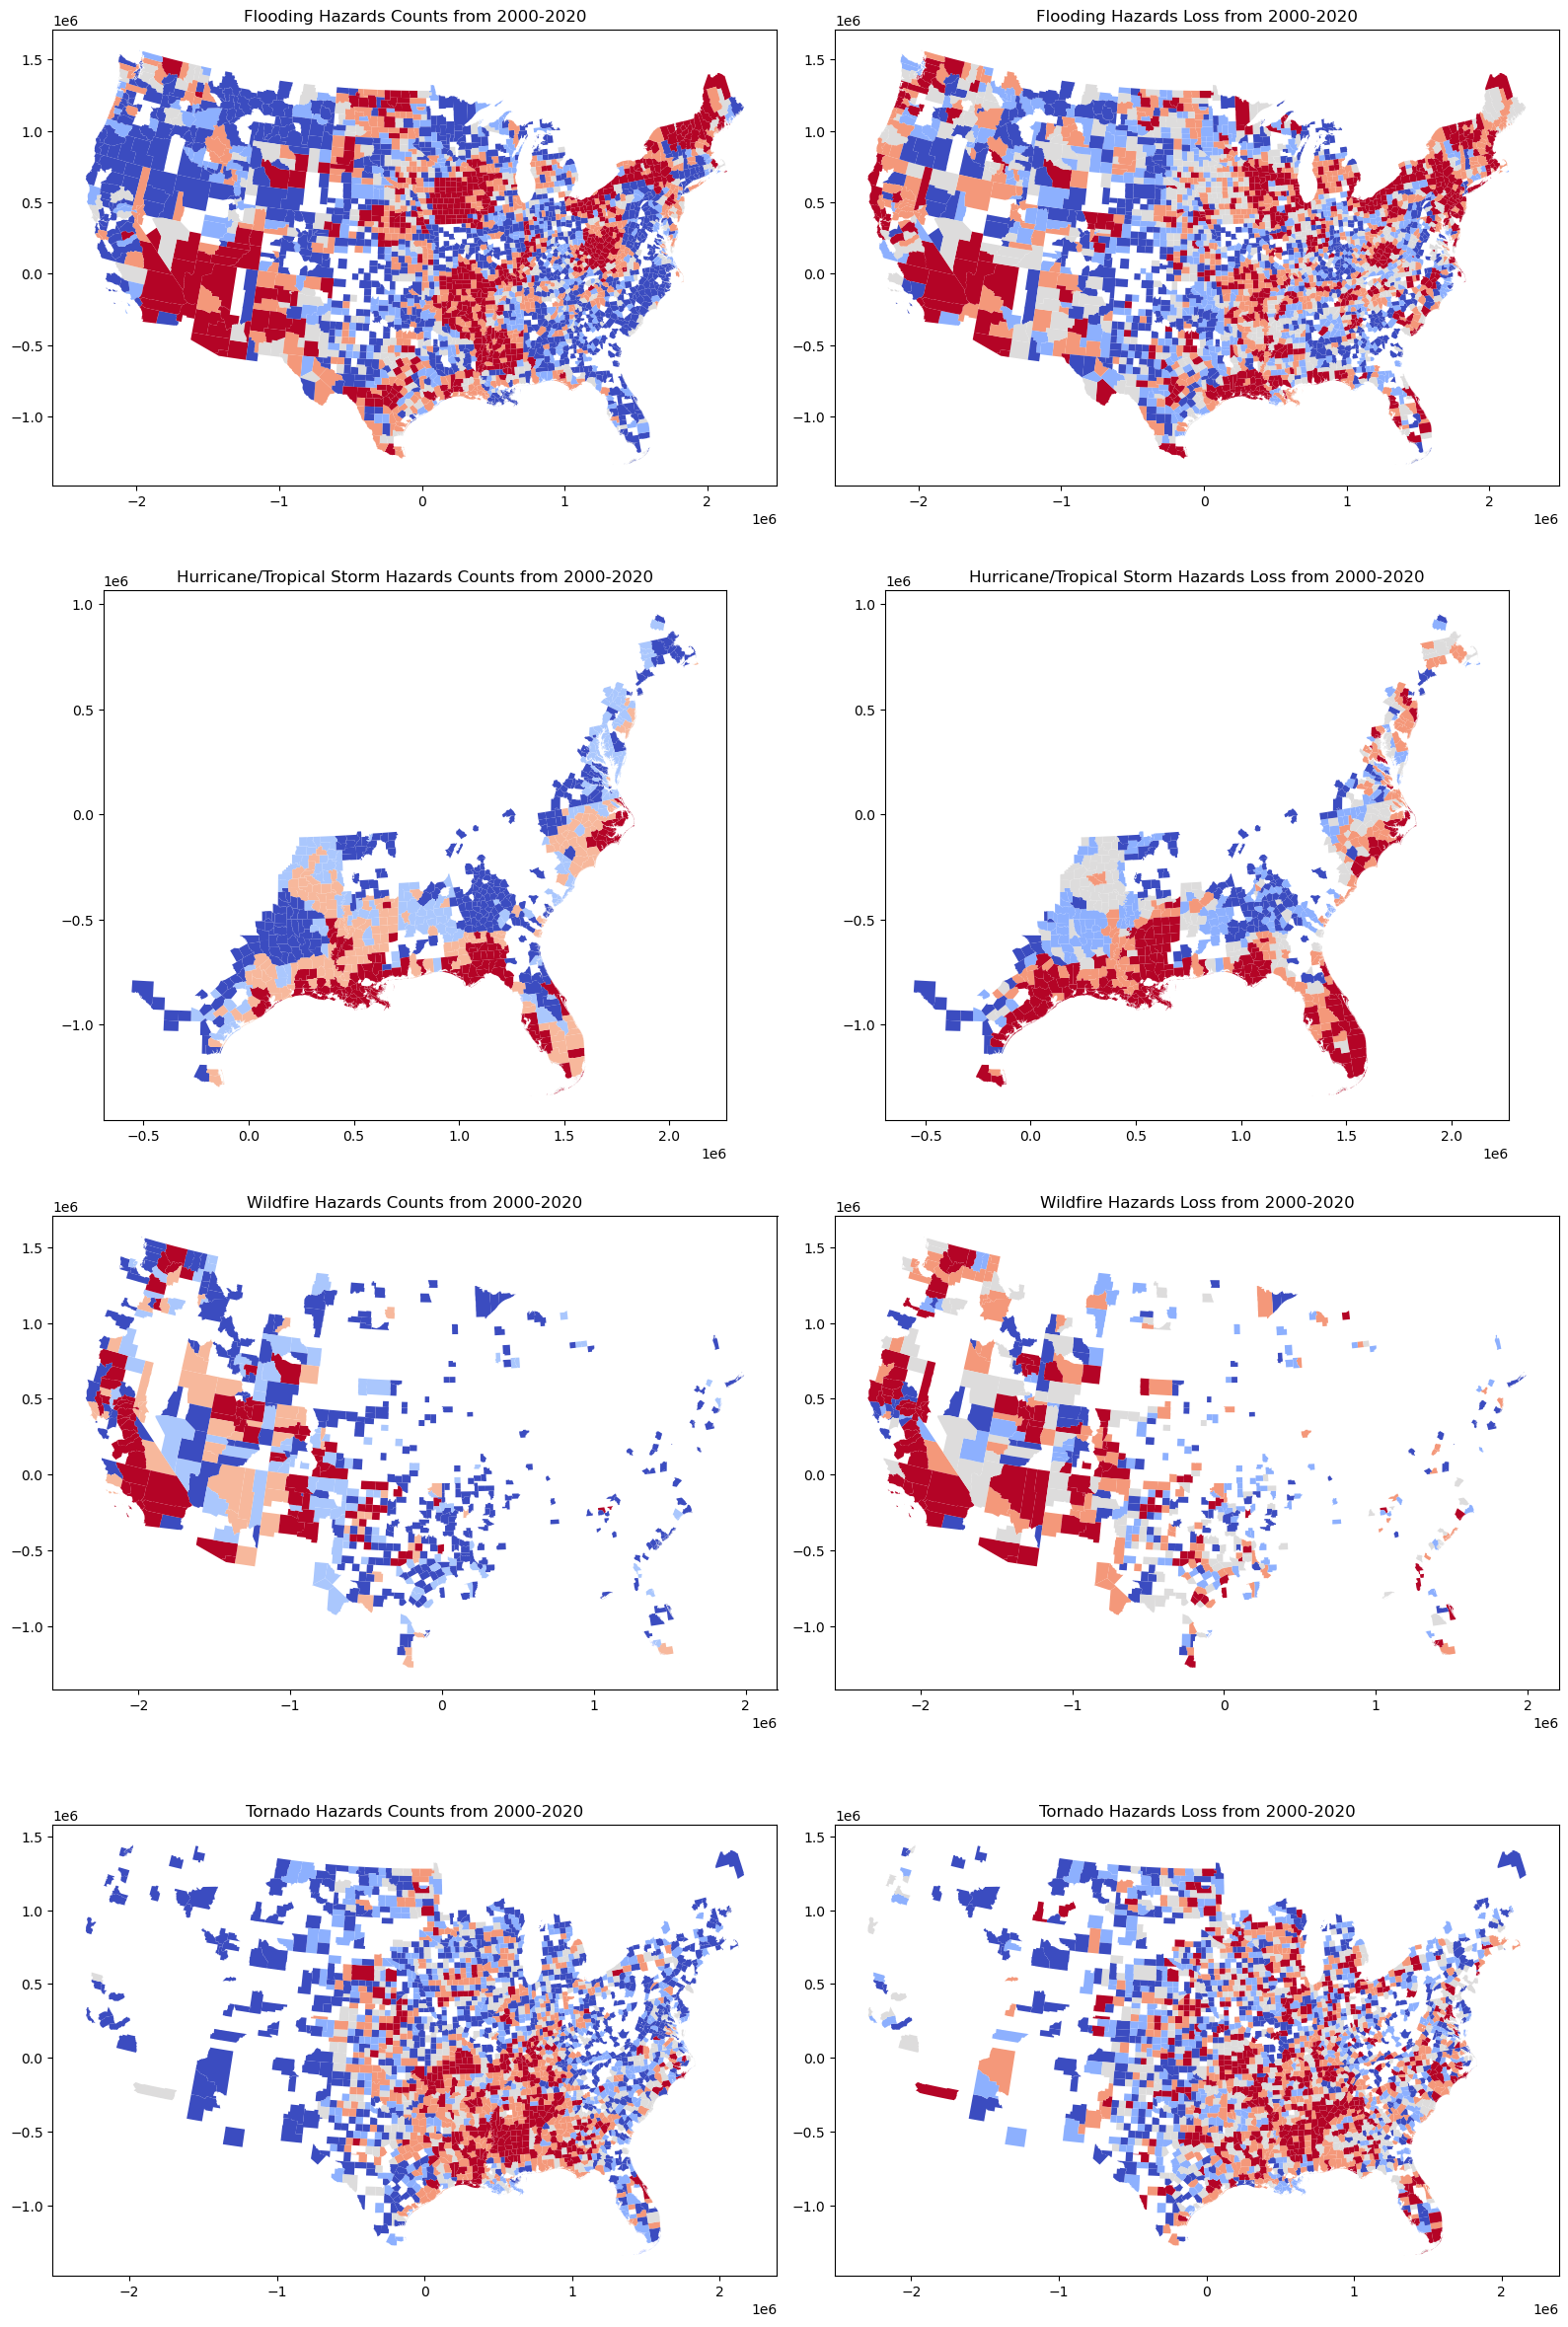

In [68]:
fig, axes = plt.subplots(4,2,figsize=(16,24))
list_disaster = ['Flooding','Hurricane/Tropical Storm','Wildfire','Tornado']
for i in range(4):
    use_df_disaster = gdf_disaster[gdf_disaster["Hazard"] == str(list_disaster[i])]
#     print(use_df_disaster.head())
    use_df_disaster.plot(column="frequency",cmap="coolwarm",scheme='quantiles',
#                          classification_kwds={'bins':[1,3,5,10,20,50]},
                         ax=axes[i,0])
    use_df_disaster.plot(column="PropertyDmg(ADJ 2020)",cmap="coolwarm",scheme="quantiles",
#                          ,legend=True,
                         ax=axes[i,1])
    axes[i,0].set_title(f"{list_disaster[i]} Hazards Counts from 2000-2020")
    axes[i,1].set_title(f"{list_disaster[i]} Hazards Loss from 2000-2020")
plt.tight_layout()
plt.show()

## XGBoost
### Combine each dataset

In [69]:
Regression_data = pd.DataFrame()
Regression_data = df_pep_0120
Regression_data = pd.merge(Regression_data,Disaster,on="FIPS",how="outer")
Regression_data = pd.merge(Regression_data,HAI,on="FIPS",how="inner")
# Regression_data = pd.merge(Regression_data,Hurricane,left_on="FIPS",right_on="County FIPS",how="outer")
# Regression_data = pd.merge(Regression_data,Wildfire,left_on="FIPS",right_on="County FIPS",how="outer")
# Regression_data = pd.merge(Regression_data,Tornado,left_on="FIPS",right_on="County FIPS",how="outer")
# Regression_data = pd.merge(Regression_data,Heat,left_on="FIPS",right_on="County FIPS",how="outer")
Regression_data = pd.merge(Regression_data,SVI_10,on="FIPS",how="inner")
# Regression_data = pd.merge(Regression_data,NRI_CONUS,on="FIPS",how="inner")
# Regression_data = pd.merge(Regression_data,unemployment_rate_pivot,on="FIPS",how="inner")
Regression_data = pd.merge(Regression_data,PopDensity_CONUS_sel,on="FIPS",how="inner")
# Regression_data = pd.merge(Regression_data,conus_annual_prices,on="FIPS",how="inner")
# Regression_data = pd.merge(Regression_data,MedianHouseValue,on="FIPS",how="inner")
Regression_data = pd.merge(Regression_data,MedianHouseIndicator,on="FIPS",how="inner")
# Regression_data = pd.merge(Regression_data,GDP_final_data,on="FIPS",how="inner")
# Regression_data = pd.merge(Regression_data,T_sel,on="FIPS",how="inner")
Regression_data = pd.merge(Regression_data,Amenity,on="FIPS",how="inner")

In [70]:
Regression_data = Regression_data.fillna(0)

In [71]:
used_list = [
    "FIPS","NetMigrationRateTotal",#PEP
    "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss",
    "E_P_POV","E_P_UNEMP","E_P_PCI","E_P_NOHSDIP","P_AGE65","P_AGE17","P_SNGPRNT",
    "P_MINORITY","E_P_LIMENG","E_P_MUNIT","E_P_MOBILE","E_P_CROWD","E_P_NOVEH","P_GROUPQ", #SVI
    "POPDENS10",#POP DENSITY
    "W_HT_HAI",#HAI
    "MedianHouseholdIncome2000(adjusted)","MedianHouseholdIncome2020",
    "%ChangeIncome","income/value2000","income/value2020",
    "%Income/%Value",#House Indicators
    'Scale' #Amenity
]

standard_list = [
    "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss",
    "E_P_POV","E_P_UNEMP","E_P_PCI","E_P_NOHSDIP","P_AGE65","P_AGE17","P_SNGPRNT",
    "P_MINORITY","E_P_LIMENG","E_P_MUNIT","E_P_MOBILE","E_P_CROWD","E_P_NOVEH","P_GROUPQ", #SVI
    "POPDENS10",#POP DENSITY
    "W_HT_HAI",#HAI
    "MedianHouseholdIncome2000(adjusted)","MedianHouseholdIncome2020",
    "%ChangeIncome","income/value2000","income/value2020",
    "%Income/%Value",#House Indicators
    'Scale' #Amenity'
]


name_list = [
    "FIPS","NMR",
    "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss",
    "%BelowPoverty","%Unemployed","PerCapitaIncome","%NoHighSchoolDiploma25+","%Age65+",
    "%Age18-","%Single-parent household","%Minority","%Age5+LessThanWellEnglish",
    "%Multi-Unit House","%MobileHome","%HousePop>Room","%NoVehicleHousehold","%GroupQuarters",
    "Pop Density",
    "HouseUnaffordability",
    "MedianHouseholdIncome2000","MedianHouseholdIncome2020",
    "%ChangeIncome","Income/Value2000","Income/Value2020",
    "%Income/%Value",#House Indicators
    'Amenity Scale' #Amenity
]    

In [72]:
Regression_data = Regression_data[~np.isinf(Regression_data['income/value2000'])]

In [73]:
Flood_Regression_data = Regression_data[Regression_data["Flood_Occur"]!=0].reset_index()
Hurricane_Regression_data = Regression_data[Regression_data["Hurricane_Occur"]!=0].reset_index()
Wildfire_Regression_data = Regression_data[Regression_data["Wildfire_Occur"]!=0].reset_index()
Tornado_Regression_data = Regression_data[Regression_data["Tornado_Occur"]!=0].reset_index()

In [74]:
scaler = RobustScaler()
Flood_Regression_data_used = Flood_Regression_data[used_list]
Flood_Regression_data_used[standard_list] = scaler.fit_transform(Flood_Regression_data_used[standard_list])
Flood_Regression_data_used.columns = name_list

Hurricane_Regression_data_used = Hurricane_Regression_data[used_list]
Hurricane_Regression_data_used[standard_list] = scaler.fit_transform(Hurricane_Regression_data_used[standard_list])
Hurricane_Regression_data_used.columns = name_list

Wildfire_Regression_data_used = Wildfire_Regression_data[used_list]
Wildfire_Regression_data_used[standard_list] = scaler.fit_transform(Wildfire_Regression_data_used[standard_list])
Wildfire_Regression_data_used.columns = name_list

Tornado_Regression_data_used = Tornado_Regression_data[used_list]
Tornado_Regression_data_used[standard_list] = scaler.fit_transform(Tornado_Regression_data_used[standard_list])
Tornado_Regression_data_used.columns = name_list

C:\Users\xiang11\AppData\Local\Temp\ipykernel_10980\925136066.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Flood_Regression_data_used[standard_list] = scaler.fit_transform(Flood_Regression_data_used[standard_list])
C:\Users\xiang11\AppData\Local\Temp\ipykernel_10980\925136066.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Hurricane_Regression_data_used[standard_list] = scaler.fit_transform(Hurricane_Regression_data_used[standard_list])
C:\Users\xiang11\AppData\Local\Temp\ipykernel_10980\92513606

## VIF is not required for XGBoost.

### XGBOOST with all factors in Hurricane, Flood, Wildfire, Tornado

## Test for the best parameters
## Flood

In [75]:
X = Flood_Regression_data_used.drop(columns=['NMR', 'FIPS',
#     "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss"
                                            ])
y = Flood_Regression_data_used['NMR']

# # Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 500, 1000],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(xgb.XGBRegressor(objective="reg:squarederror"), param_grid, scoring="neg_mean_squared_error", cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 1000, 'subsample': 0.8}


## Hurricane

In [76]:
X = Hurricane_Regression_data_used.drop(columns=['NMR', 'FIPS',
    "Flood_Frequency","Flood_Loss",
#     "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss"
                                            ])
y = Hurricane_Regression_data_used['NMR']

# # Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 500, 1000],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(xgb.XGBRegressor(objective="reg:squarederror"), param_grid, scoring="neg_mean_squared_error", cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 0.8}


## Wildfire

In [77]:
X = Wildfire_Regression_data_used.drop(columns=['NMR', 'FIPS',
    "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
#     "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss"
                                            ])
y = Wildfire_Regression_data_used['NMR']

# # Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 500, 1000],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(xgb.XGBRegressor(objective="reg:squarederror"), param_grid, scoring="neg_mean_squared_error", cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 0.8}


## Tornado

In [78]:
X = Tornado_Regression_data_used.drop(columns=['NMR', 'FIPS',
#     "Flood_Frequency","Flood_Loss",
#     "Hurricane_Frequency","Hurricane_Loss",
#     "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss"
                                            ])
y = Tornado_Regression_data_used['NMR']

# # Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 500, 1000],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(xgb.XGBRegressor(objective="reg:squarederror"), param_grid, scoring="neg_mean_squared_error", cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 1000, 'subsample': 0.8}


## Results of XGBoost Flood

Mean Squared Error: 21.36649747978913


100%|===================| 692/693 [00:33<00:00]        

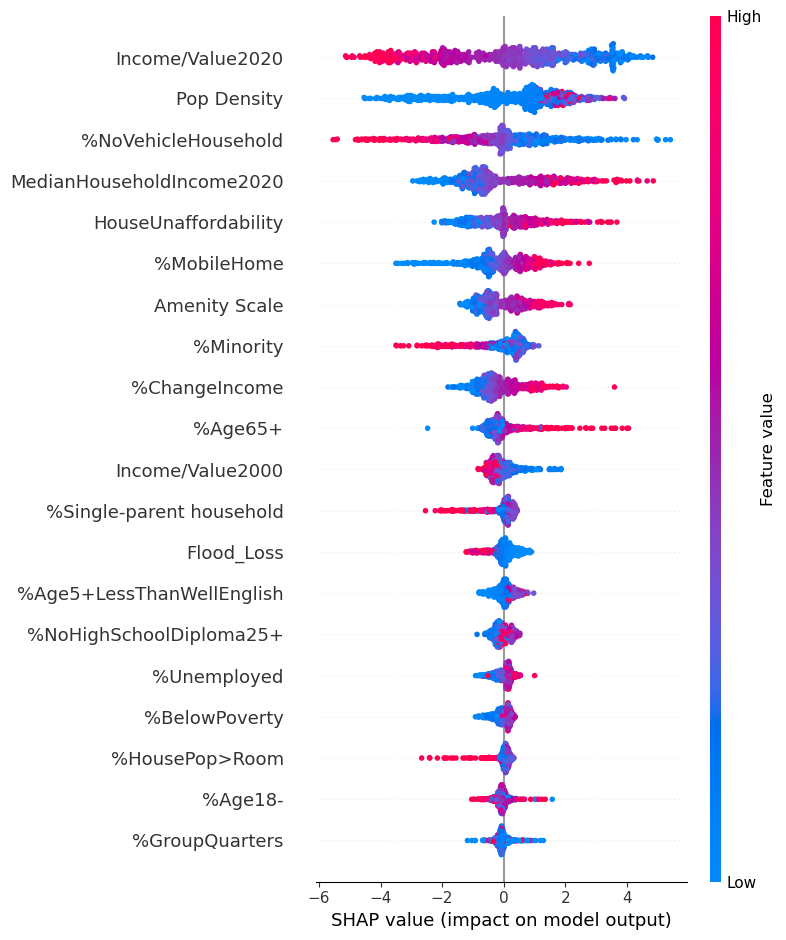

In [79]:
X = Flood_Regression_data_used.drop(columns=['NMR', 'FIPS',
#     "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss"
                                            ])
y = Flood_Regression_data_used['NMR']

# # Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# # Train an XGBoost regression model
model = xgb.XGBRegressor(objective='reg:squarederror',
                             n_estimators=1000,  
    learning_rate=0.01,
    max_depth=6,  
    subsample=0.8,  
    colsample_bytree=0.8,
    reg_lambda=1,  
    reg_alpha=0,  
    missing=0)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Explain the model with SHAP
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Summary plot of feature importance
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
# plt.savefig(r'F:\LongMig2025\results\maps\xgboost\summary.png', dpi=600, bbox_inches='tight')
fig.clf()

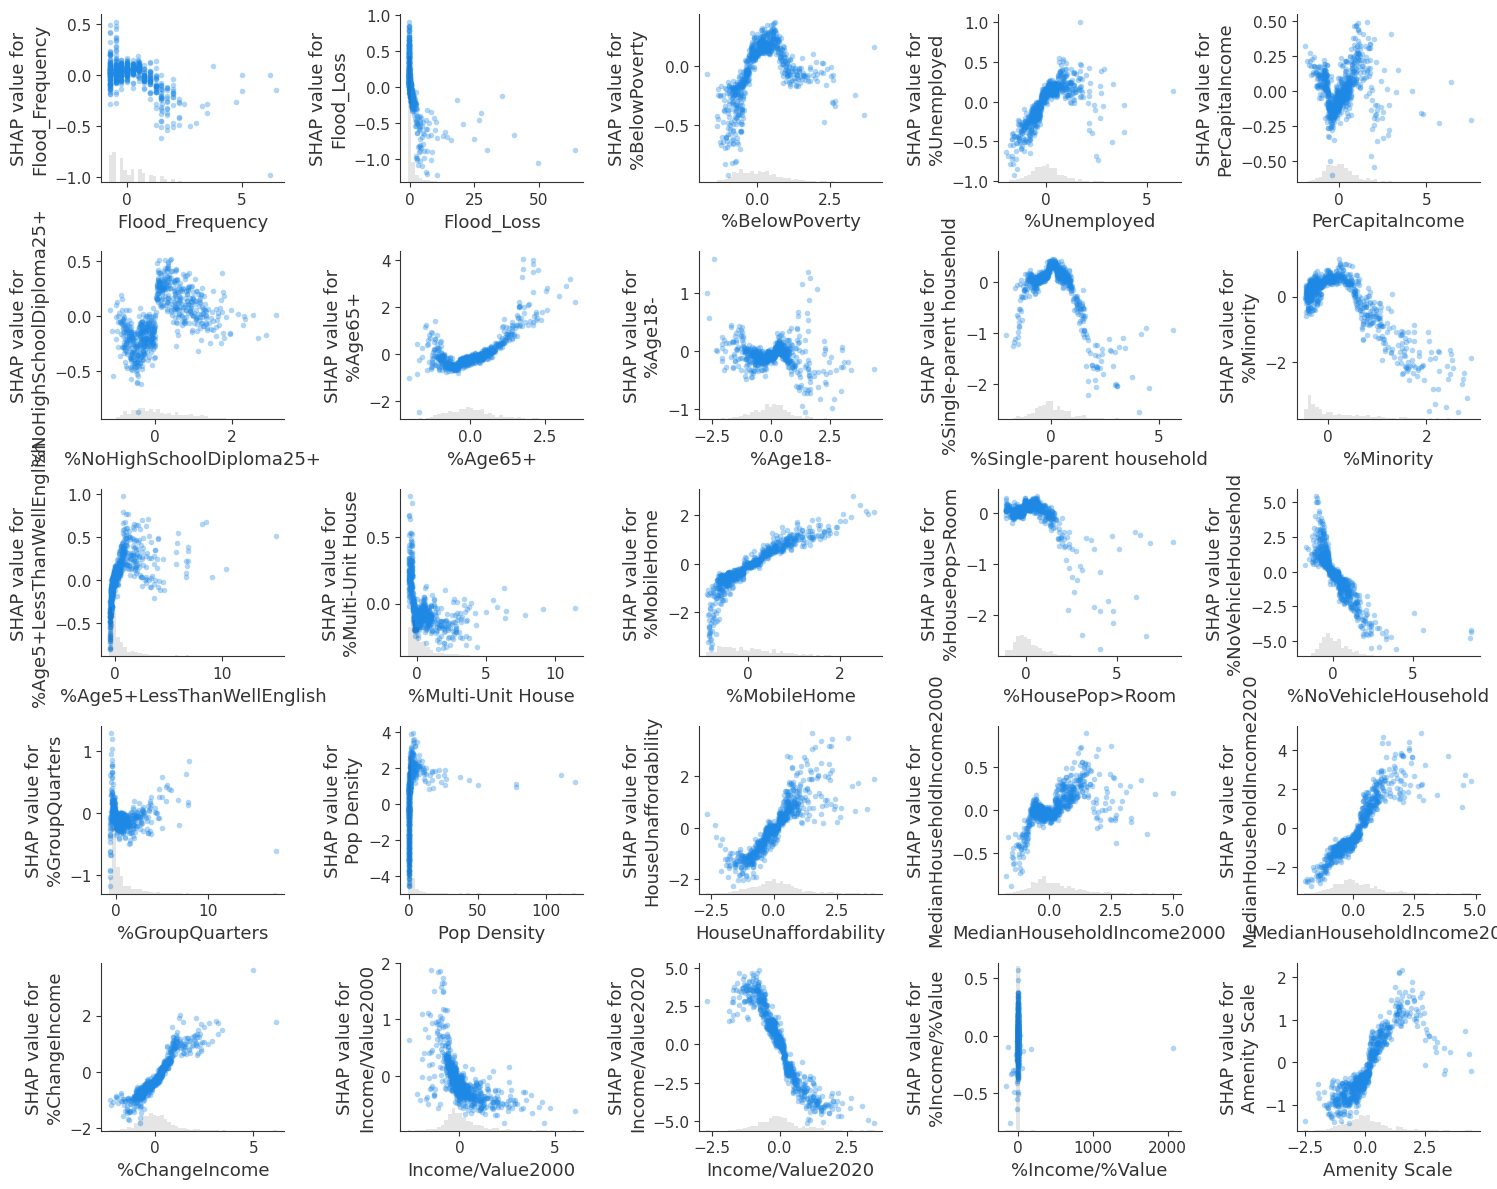

In [80]:
# Define all the features in your dataset
all_features = X_test.columns  # Replace with the features from your test set

# Set up the number of rows and columns for subplots
num_features = len(all_features)
cols = 5  # Number of columns in the subplot grid
rows = (num_features + cols - 1) // cols  # Calculate the number of rows needed

# Create the subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 12))

# Flatten axes for easy iteration
axes = axes.flatten()

# Generate SHAP dependence plots for each feature
for i, feature in enumerate(all_features):
    shap.plots.scatter(shap_values[:, feature],ax=axes[i], show=False, alpha=0.35)
#     sns.regplot(x=X_test[feature], y=shap_values[:, feature], ax=axes[i], scatter_kws={'s': 10}, line_kws={'color': 'red'})
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
#     shap.dependence_plot(
#         feature, shap_values.values, X_test, ax=axes[i], show=False
#     )
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
    

# Turn off unused subplots if the number of features is less than total subplots
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")
# plt.savefig(r'F:\LongMig2025\results\maps\xgboost\dependence.png', dpi=600, bbox_inches='tight')  # Specify the path and file name here

# Show the final figure
plt.tight_layout()
plt.show()


In [81]:
r2 = r2_score(y_test, y_pred)

# RMSE (Root Mean Squared Error)
rmse = mean_squared_error(y_test, y_pred, squared=False)

# ME (Mean Error, aka Bias)
me = (y_test - y_pred).mean()

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"Mean Error (ME): {me:.3f}")


R²: 0.697
RMSE: 4.622
Mean Error (ME): -0.312


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Remove Flood Variables

Mean Squared Error: 21.635388988492537


100%|===================| 690/693 [00:34<00:00]        

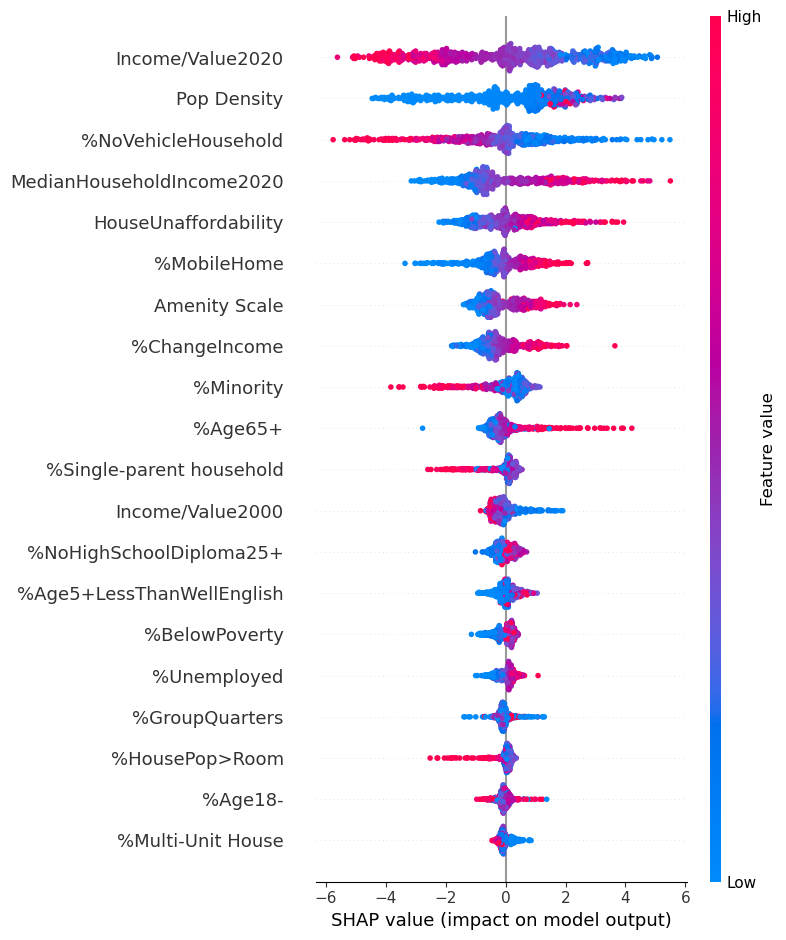

In [82]:
X = Flood_Regression_data_used.drop(columns=['NMR', 'FIPS',
    "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss"
                                            ])
y = Flood_Regression_data_used['NMR']

# # Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# # Train an XGBoost regression model
model = xgb.XGBRegressor(objective='reg:squarederror',
                             n_estimators=1000,  
    learning_rate=0.01,
    max_depth=6,  
    subsample=0.8,  
    colsample_bytree=0.8,
    reg_lambda=1,  
    reg_alpha=0,  
    missing=0)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Explain the model with SHAP
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Summary plot of feature importance
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
# plt.savefig(r'F:\LongMig2025\results\maps\xgboost\summary.png', dpi=600, bbox_inches='tight')
fig.clf()

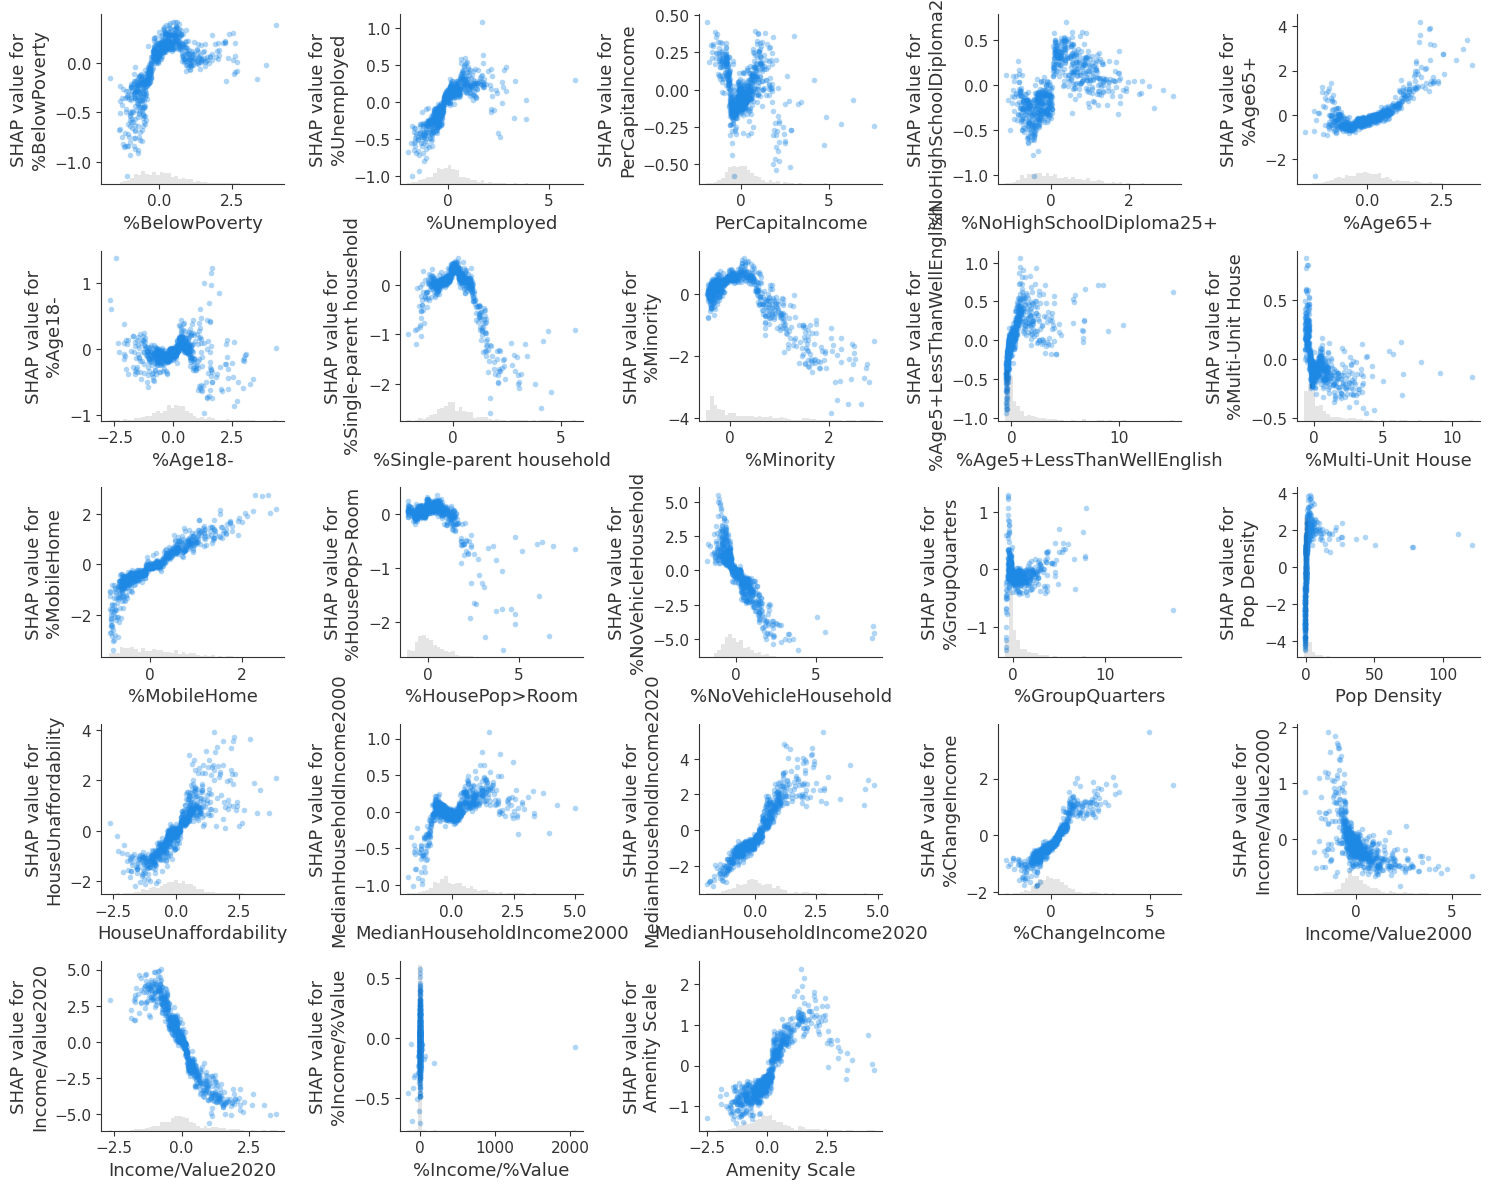

In [83]:
# Define all the features in your dataset
all_features = X_test.columns  # Replace with the features from your test set

# Set up the number of rows and columns for subplots
num_features = len(all_features)
cols = 5  # Number of columns in the subplot grid
rows = (num_features + cols - 1) // cols  # Calculate the number of rows needed

# Create the subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 12))

# Flatten axes for easy iteration
axes = axes.flatten()

# Generate SHAP dependence plots for each feature
for i, feature in enumerate(all_features):
    shap.plots.scatter(shap_values[:, feature],ax=axes[i], show=False, alpha=0.35)
#     sns.regplot(x=X_test[feature], y=shap_values[:, feature], ax=axes[i], scatter_kws={'s': 10}, line_kws={'color': 'red'})
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
#     shap.dependence_plot(
#         feature, shap_values.values, X_test, ax=axes[i], show=False
#     )
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
    

# Turn off unused subplots if the number of features is less than total subplots
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")
# plt.savefig(r'F:\LongMig2025\results\maps\xgboost\dependence.png', dpi=600, bbox_inches='tight')  # Specify the path and file name here

# Show the final figure
plt.tight_layout()
plt.show()


In [84]:
r2 = r2_score(y_test, y_pred)

# RMSE (Root Mean Squared Error)
rmse = mean_squared_error(y_test, y_pred, squared=False)

# ME (Mean Error, aka Bias)
me = (y_test - y_pred).mean()

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"Mean Error (ME): {me:.3f}")


R²: 0.693
RMSE: 4.651
Mean Error (ME): -0.331


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Results of XGBoost Hurricane

Mean Squared Error: 24.967388186011576


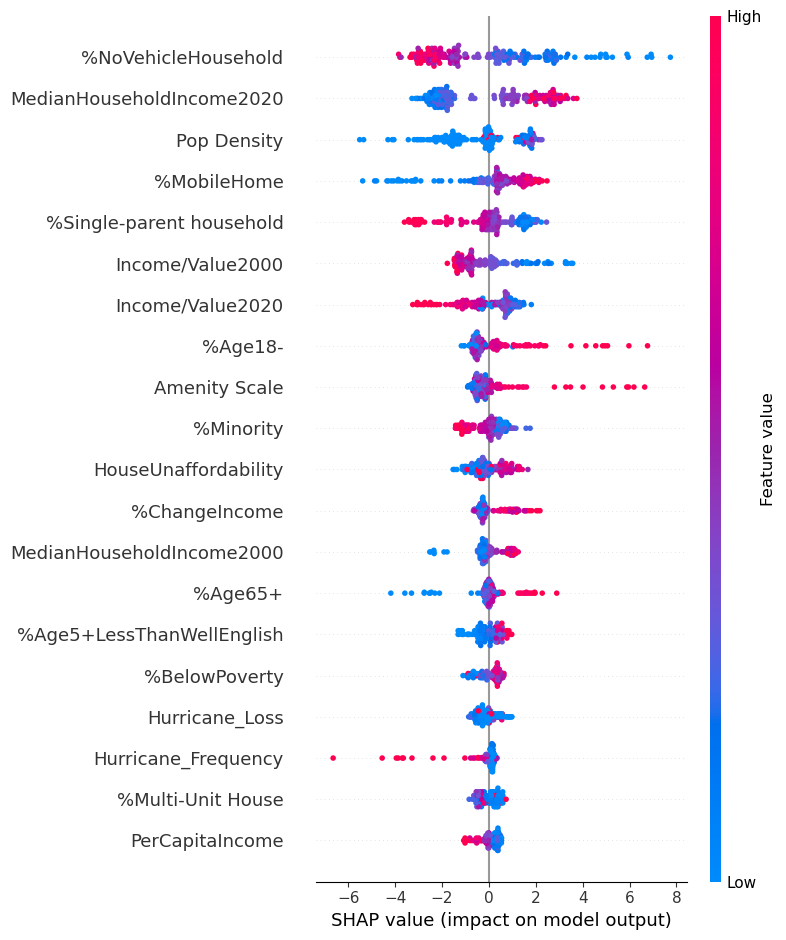

In [85]:
X = Hurricane_Regression_data_used.drop(columns=['NMR', 'FIPS',
    "Flood_Frequency","Flood_Loss",
#     "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss"
                                            ])
y = Hurricane_Regression_data_used['NMR']

# # Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# # Train an XGBoost regression model
model = xgb.XGBRegressor(objective='reg:squarederror',
                             n_estimators=500,  
    learning_rate=0.05,
    max_depth=3,  
    subsample=0.8,  
    colsample_bytree=0.8,
    reg_lambda=1,  
    reg_alpha=0,  
    missing=0)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Explain the model with SHAP
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Summary plot of feature importance
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
# plt.savefig(r'F:\LongMig2025\results\maps\xgboost\summary.png', dpi=600, bbox_inches='tight')
fig.clf()

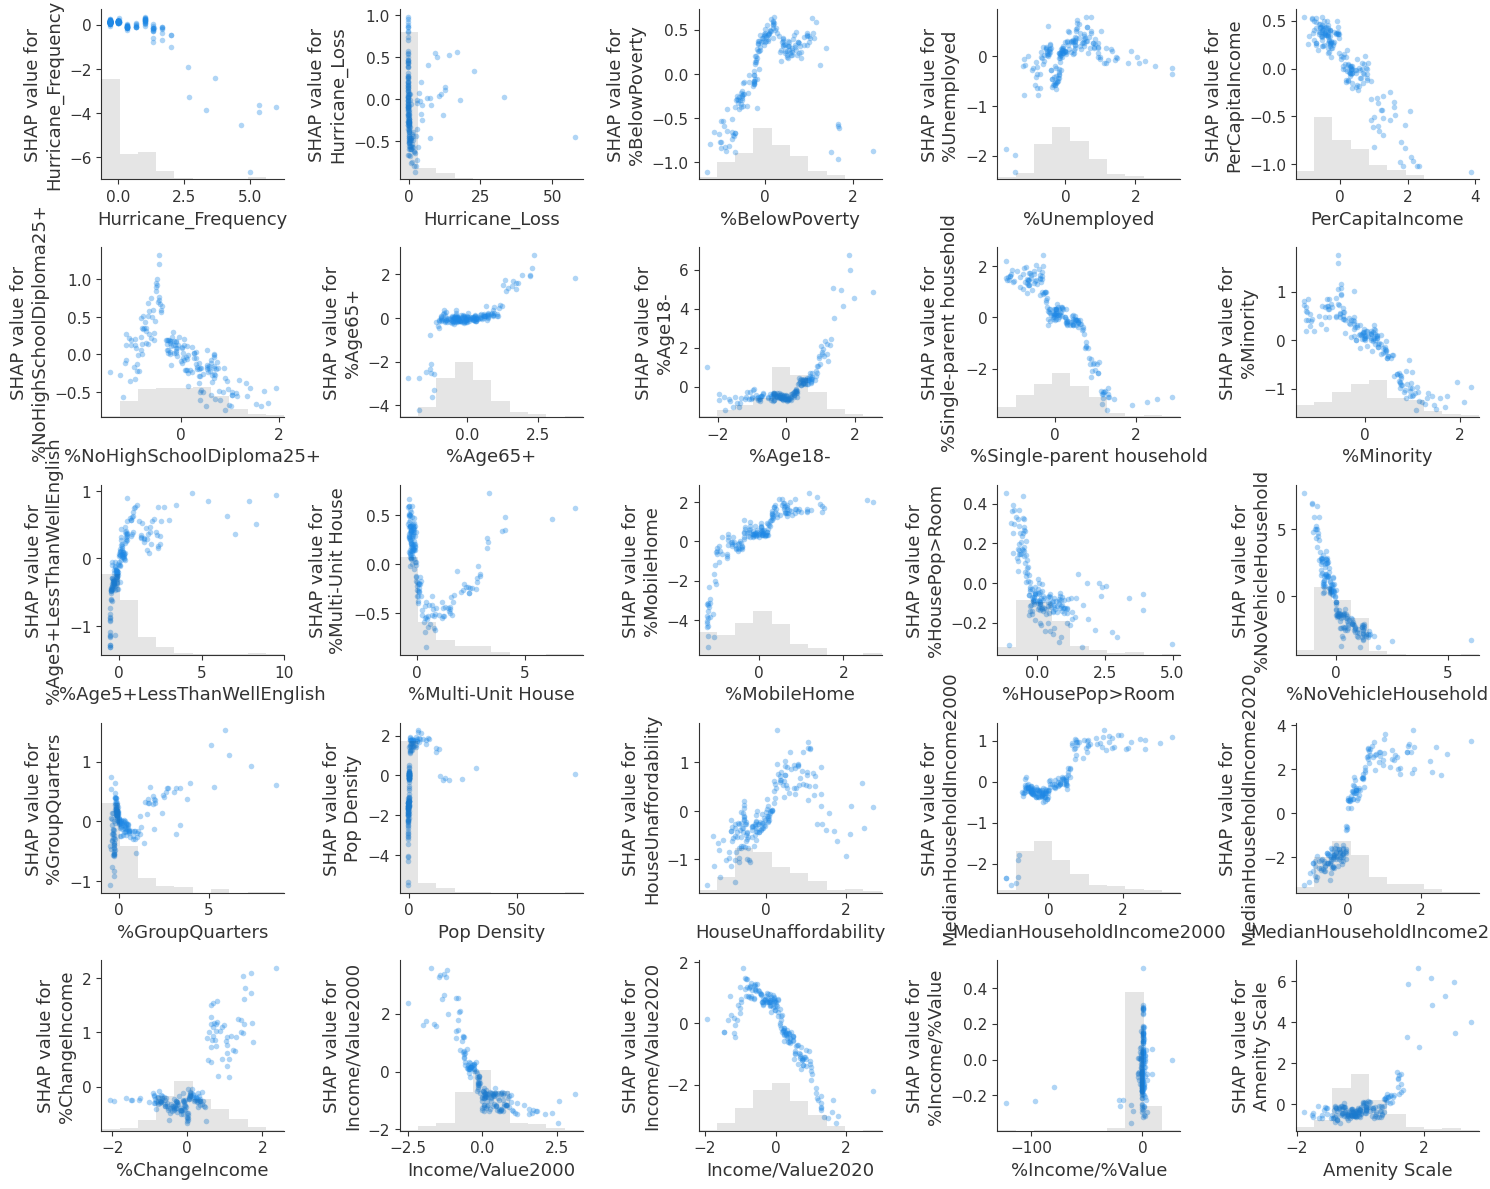

In [86]:
# Define all the features in your dataset
all_features = X_test.columns  # Replace with the features from your test set

# Set up the number of rows and columns for subplots
num_features = len(all_features)
cols = 5  # Number of columns in the subplot grid
rows = (num_features + cols - 1) // cols  # Calculate the number of rows needed

# Create the subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 12))

# Flatten axes for easy iteration
axes = axes.flatten()

# Generate SHAP dependence plots for each feature
for i, feature in enumerate(all_features):
    shap.plots.scatter(shap_values[:, feature],ax=axes[i], show=False, alpha=0.35)
#     sns.regplot(x=X_test[feature], y=shap_values[:, feature], ax=axes[i], scatter_kws={'s': 10}, line_kws={'color': 'red'})
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
#     shap.dependence_plot(
#         feature, shap_values.values, X_test, ax=axes[i], show=False
#     )
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
    

# Turn off unused subplots if the number of features is less than total subplots
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")
# plt.savefig(r'F:\LongMig2025\results\maps\xgboost\dependence.png', dpi=600, bbox_inches='tight')  # Specify the path and file name here

# Show the final figure
plt.tight_layout()
plt.show()


In [87]:
r2 = r2_score(y_test, y_pred)

# RMSE (Root Mean Squared Error)
rmse = mean_squared_error(y_test, y_pred, squared=False)

# ME (Mean Error, aka Bias)
me = (y_test - y_pred).mean()

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"Mean Error (ME): {me:.3f}")


R²: 0.726
RMSE: 4.997
Mean Error (ME): 0.263


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Remove Hurricane Variables

Mean Squared Error: 27.847986952925517


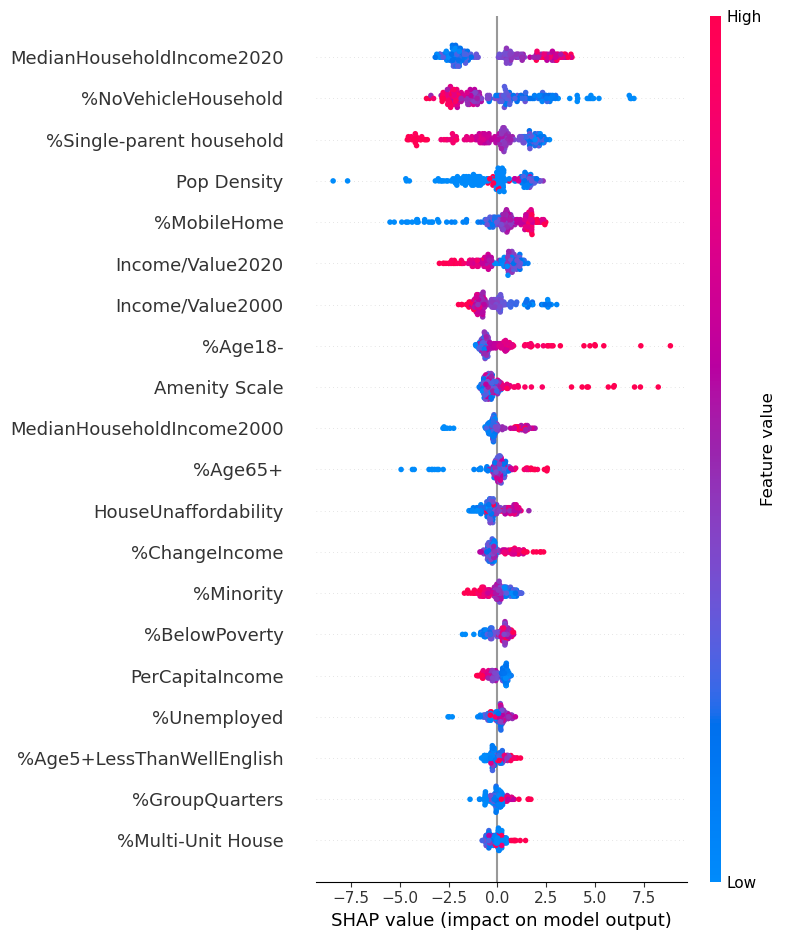

In [88]:
X = Hurricane_Regression_data_used.drop(columns=['NMR', 'FIPS',
    "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss"
                                            ])
y = Hurricane_Regression_data_used['NMR']

# # Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# # Train an XGBoost regression model
model = xgb.XGBRegressor(objective='reg:squarederror',
                             n_estimators=500,  
    learning_rate=0.05,
    max_depth=3,  
    subsample=0.8,  
    colsample_bytree=0.8,
    reg_lambda=1,  
    reg_alpha=0,  
    missing=0)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Explain the model with SHAP
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Summary plot of feature importance
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
# plt.savefig(r'F:\LongMig2025\results\maps\xgboost\summary.png', dpi=600, bbox_inches='tight')
fig.clf()

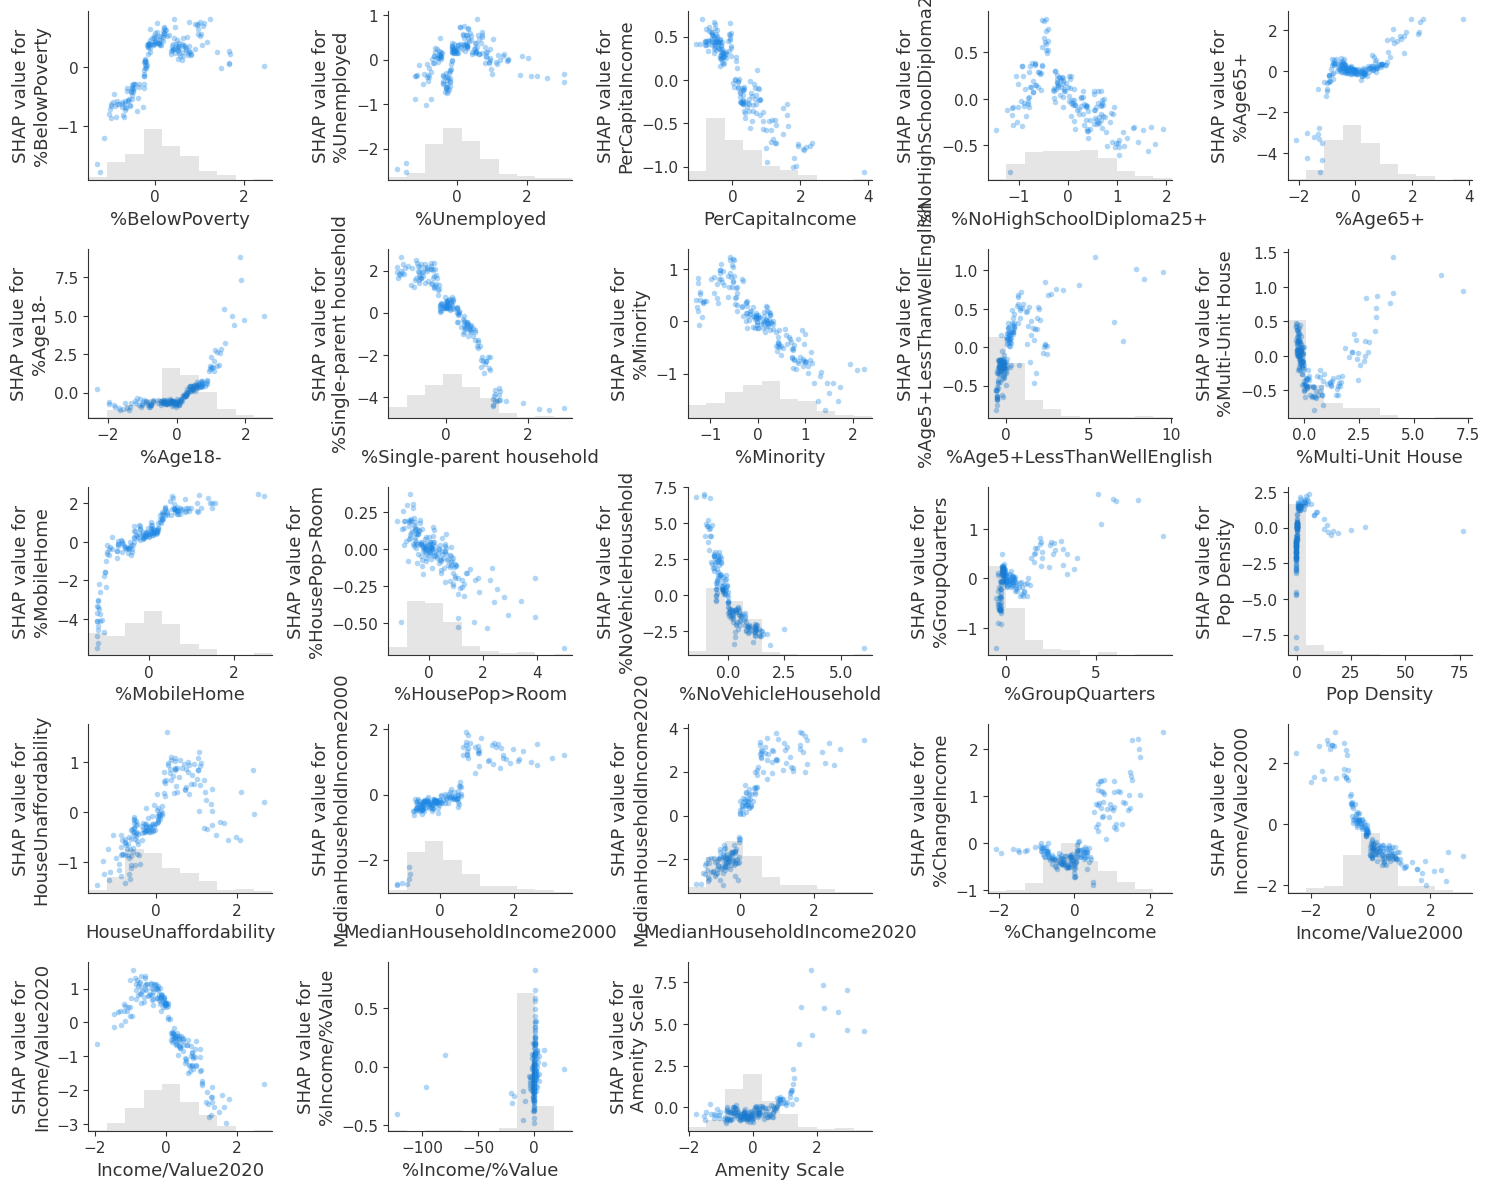

In [89]:
# Define all the features in your dataset
all_features = X_test.columns  # Replace with the features from your test set

# Set up the number of rows and columns for subplots
num_features = len(all_features)
cols = 5  # Number of columns in the subplot grid
rows = (num_features + cols - 1) // cols  # Calculate the number of rows needed

# Create the subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 12))

# Flatten axes for easy iteration
axes = axes.flatten()

# Generate SHAP dependence plots for each feature
for i, feature in enumerate(all_features):
    shap.plots.scatter(shap_values[:, feature],ax=axes[i], show=False, alpha=0.35)
#     sns.regplot(x=X_test[feature], y=shap_values[:, feature], ax=axes[i], scatter_kws={'s': 10}, line_kws={'color': 'red'})
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
#     shap.dependence_plot(
#         feature, shap_values.values, X_test, ax=axes[i], show=False
#     )
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
    

# Turn off unused subplots if the number of features is less than total subplots
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")
# plt.savefig(r'F:\LongMig2025\results\maps\xgboost\dependence.png', dpi=600, bbox_inches='tight')  # Specify the path and file name here

# Show the final figure
plt.tight_layout()
plt.show()


In [90]:
r2 = r2_score(y_test, y_pred)

# RMSE (Root Mean Squared Error)
rmse = mean_squared_error(y_test, y_pred, squared=False)

# ME (Mean Error, aka Bias)
me = (y_test - y_pred).mean()

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"Mean Error (ME): {me:.3f}")


R²: 0.695
RMSE: 5.277
Mean Error (ME): 0.166


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Results of XGBoost Wildfire

Mean Squared Error: 39.02932744322944


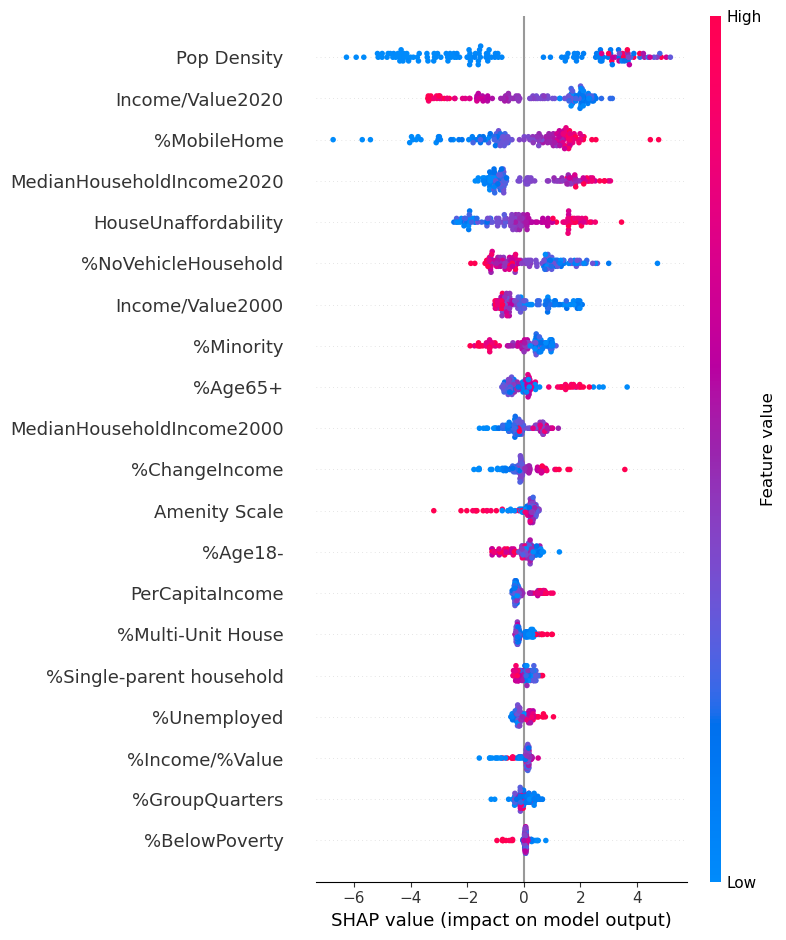

In [91]:
X = Wildfire_Regression_data_used.drop(columns=['NMR', 'FIPS',
    "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
#     "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss"
                                            ])
y = Wildfire_Regression_data_used['NMR']

# # Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# # Train an XGBoost regression model
model = xgb.XGBRegressor(objective='reg:squarederror',
                             n_estimators=1000,  
    learning_rate=0.01,
    max_depth=3,  
    subsample=0.8,  
    colsample_bytree=0.8,
    reg_lambda=1,  
    reg_alpha=0,  
    missing=0)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Explain the model with SHAP
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Summary plot of feature importance
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
# plt.savefig(r'F:\LongMig2025\results\maps\xgboost\summary.png', dpi=600, bbox_inches='tight')
fig.clf()

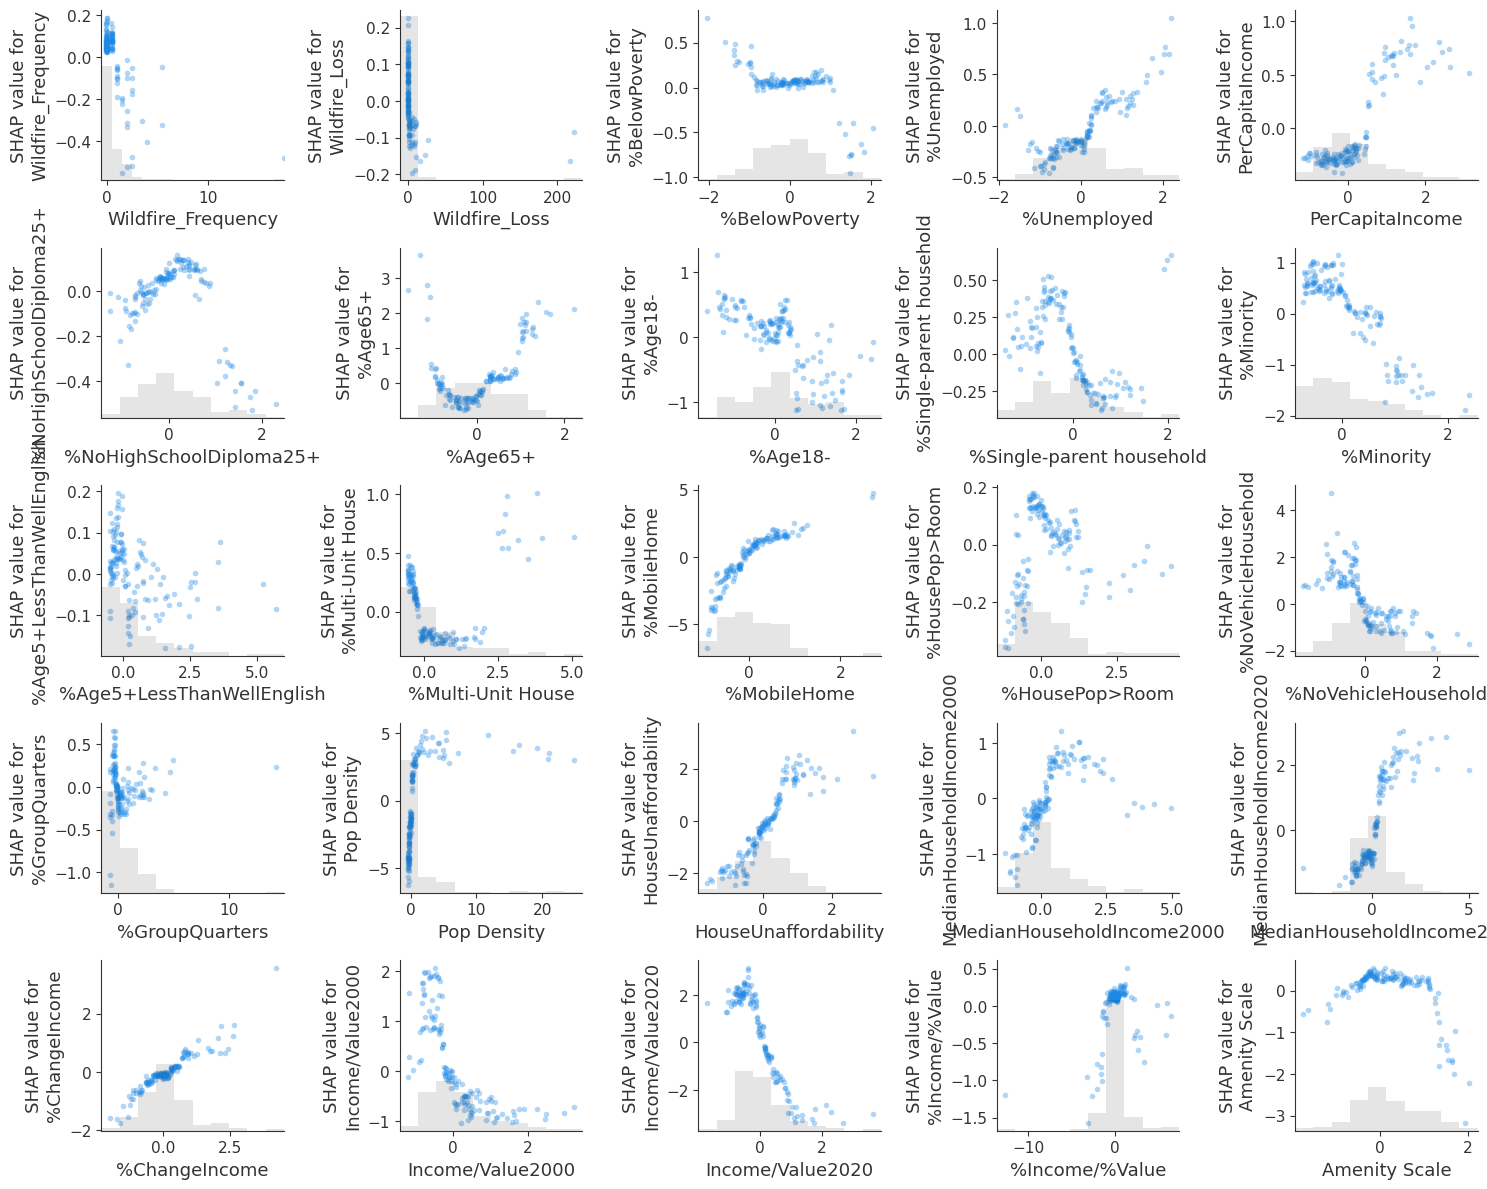

In [92]:
# Define all the features in your dataset
all_features = X_test.columns  # Replace with the features from your test set

# Set up the number of rows and columns for subplots
num_features = len(all_features)
cols = 5  # Number of columns in the subplot grid
rows = (num_features + cols - 1) // cols  # Calculate the number of rows needed

# Create the subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 12))

# Flatten axes for easy iteration
axes = axes.flatten()

# Generate SHAP dependence plots for each feature
for i, feature in enumerate(all_features):
    shap.plots.scatter(shap_values[:, feature],ax=axes[i], show=False, alpha=0.35)
#     sns.regplot(x=X_test[feature], y=shap_values[:, feature], ax=axes[i], scatter_kws={'s': 10}, line_kws={'color': 'red'})
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
#     shap.dependence_plot(
#         feature, shap_values.values, X_test, ax=axes[i], show=False
#     )
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
    

# Turn off unused subplots if the number of features is less than total subplots
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")
# plt.savefig(r'F:\LongMig2025\results\maps\xgboost\dependence.png', dpi=600, bbox_inches='tight')  # Specify the path and file name here

# Show the final figure
plt.tight_layout()
plt.show()


In [93]:
r2 = r2_score(y_test, y_pred)

# RMSE (Root Mean Squared Error)
rmse = mean_squared_error(y_test, y_pred, squared=False)

# ME (Mean Error, aka Bias)
me = (y_test - y_pred).mean()

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"Mean Error (ME): {me:.3f}")


R²: 0.609
RMSE: 6.247
Mean Error (ME): -0.834


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Remove Wildfire Variables

Mean Squared Error: 39.16325125387676


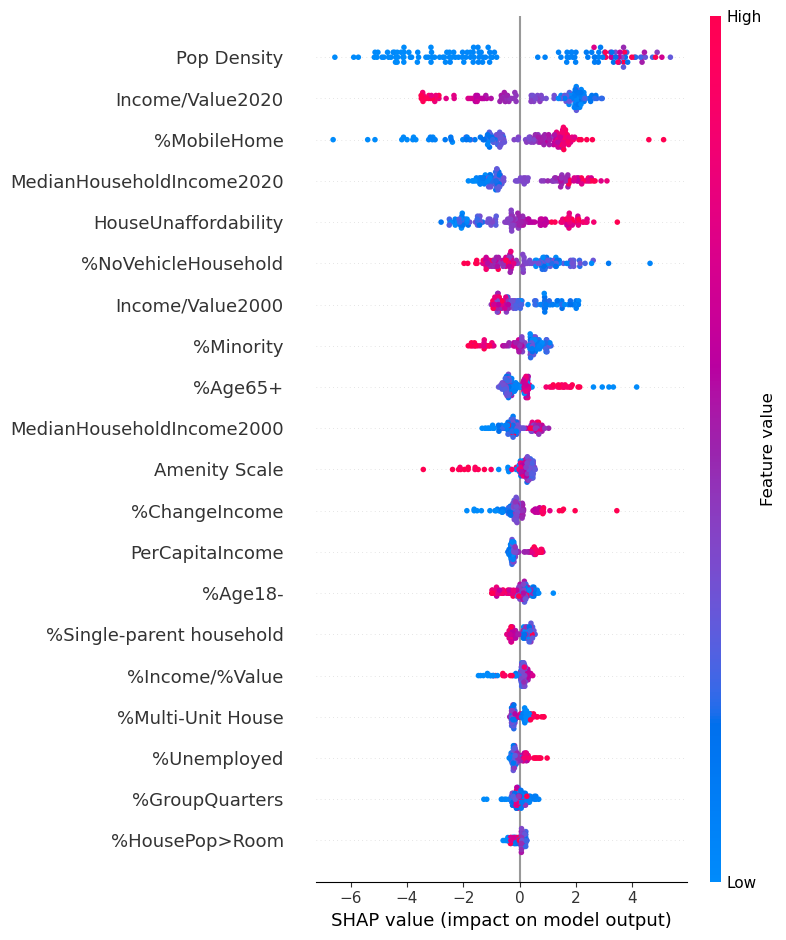

In [94]:
X = Wildfire_Regression_data_used.drop(columns=['NMR', 'FIPS',
    "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss"
                                            ])
y = Wildfire_Regression_data_used['NMR']

# # Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# # Train an XGBoost regression model
model = xgb.XGBRegressor(objective='reg:squarederror',
                             n_estimators=1000,  
    learning_rate=0.01,
    max_depth=3,  
    subsample=0.8,  
    colsample_bytree=0.8,
    reg_lambda=1,  
    reg_alpha=0,  
    missing=0)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Explain the model with SHAP
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Summary plot of feature importance
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
# plt.savefig(r'F:\LongMig2025\results\maps\xgboost\summary.png', dpi=600, bbox_inches='tight')
fig.clf()

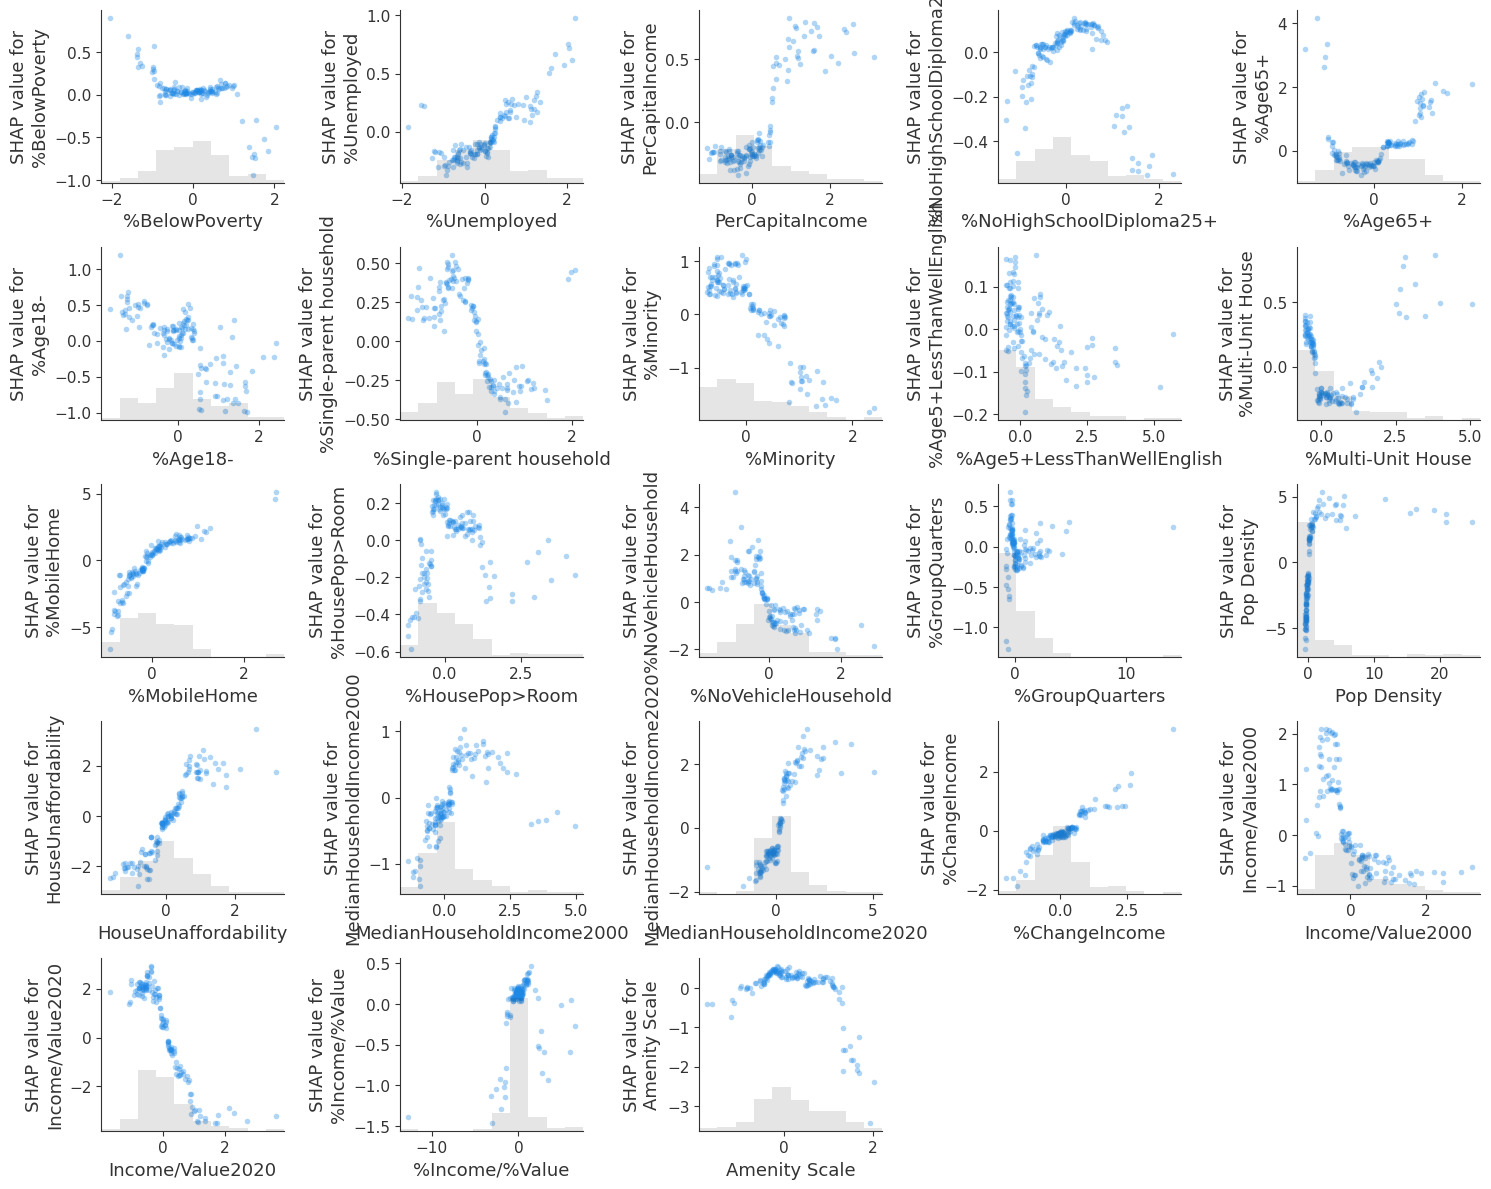

In [95]:
# Define all the features in your dataset
all_features = X_test.columns  # Replace with the features from your test set

# Set up the number of rows and columns for subplots
num_features = len(all_features)
cols = 5  # Number of columns in the subplot grid
rows = (num_features + cols - 1) // cols  # Calculate the number of rows needed

# Create the subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 12))

# Flatten axes for easy iteration
axes = axes.flatten()

# Generate SHAP dependence plots for each feature
for i, feature in enumerate(all_features):
    shap.plots.scatter(shap_values[:, feature],ax=axes[i], show=False, alpha=0.35)
#     sns.regplot(x=X_test[feature], y=shap_values[:, feature], ax=axes[i], scatter_kws={'s': 10}, line_kws={'color': 'red'})
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
#     shap.dependence_plot(
#         feature, shap_values.values, X_test, ax=axes[i], show=False
#     )
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
    

# Turn off unused subplots if the number of features is less than total subplots
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")
# plt.savefig(r'F:\LongMig2025\results\maps\xgboost\dependence.png', dpi=600, bbox_inches='tight')  # Specify the path and file name here

# Show the final figure
plt.tight_layout()
plt.show()


In [96]:
r2 = r2_score(y_test, y_pred)

# RMSE (Root Mean Squared Error)
rmse = mean_squared_error(y_test, y_pred, squared=False)

# ME (Mean Error, aka Bias)
me = (y_test - y_pred).mean()

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"Mean Error (ME): {me:.3f}")


R²: 0.608
RMSE: 6.258
Mean Error (ME): -0.746


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Results of XGBoost Tornado

Mean Squared Error: 27.767418834133636


 99%|===================| 563/566 [00:25<00:00]        

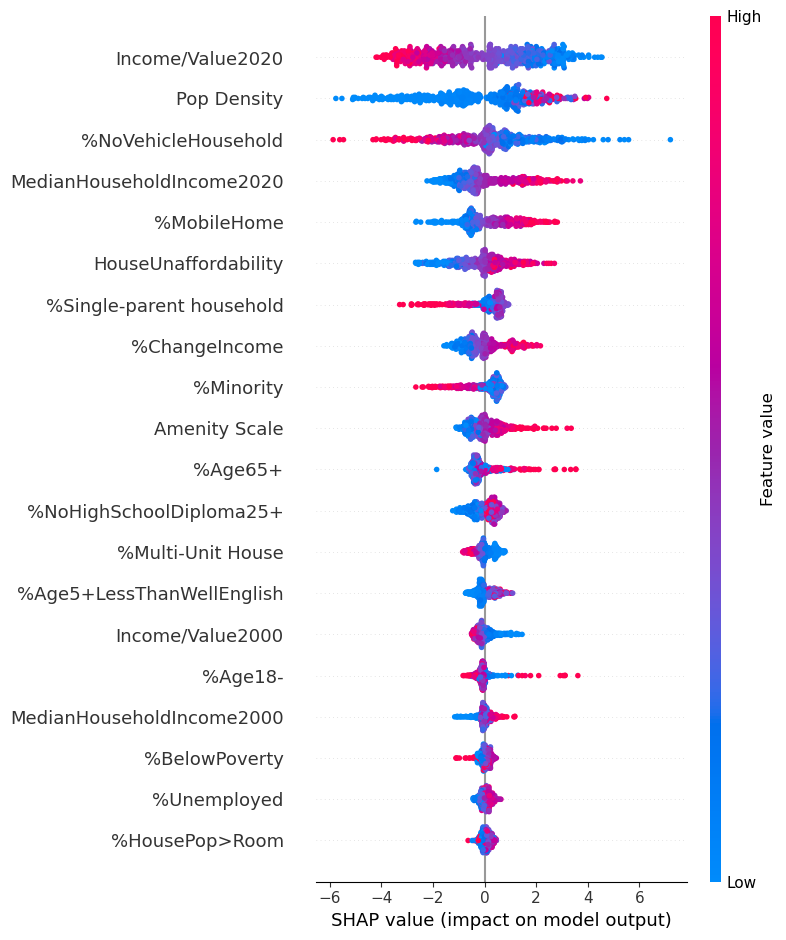

In [97]:
X = Tornado_Regression_data_used.drop(columns=['NMR', 'FIPS',
    "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
#     "Tornado_Frequency","Tornado_Loss"
                                            ])
y = Tornado_Regression_data_used['NMR']

# # Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# # Train an XGBoost regression model
model = xgb.XGBRegressor(objective='reg:squarederror',
                             n_estimators=1000,  
    learning_rate=0.01,
    max_depth=6,  
    subsample=0.8,  
    colsample_bytree=0.8,
    reg_lambda=1,  
    reg_alpha=0,  
    missing=0)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Explain the model with SHAP
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Summary plot of feature importance
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
# plt.savefig(r'F:\LongMig2025\results\maps\xgboost\summary.png', dpi=600, bbox_inches='tight')
fig.clf()

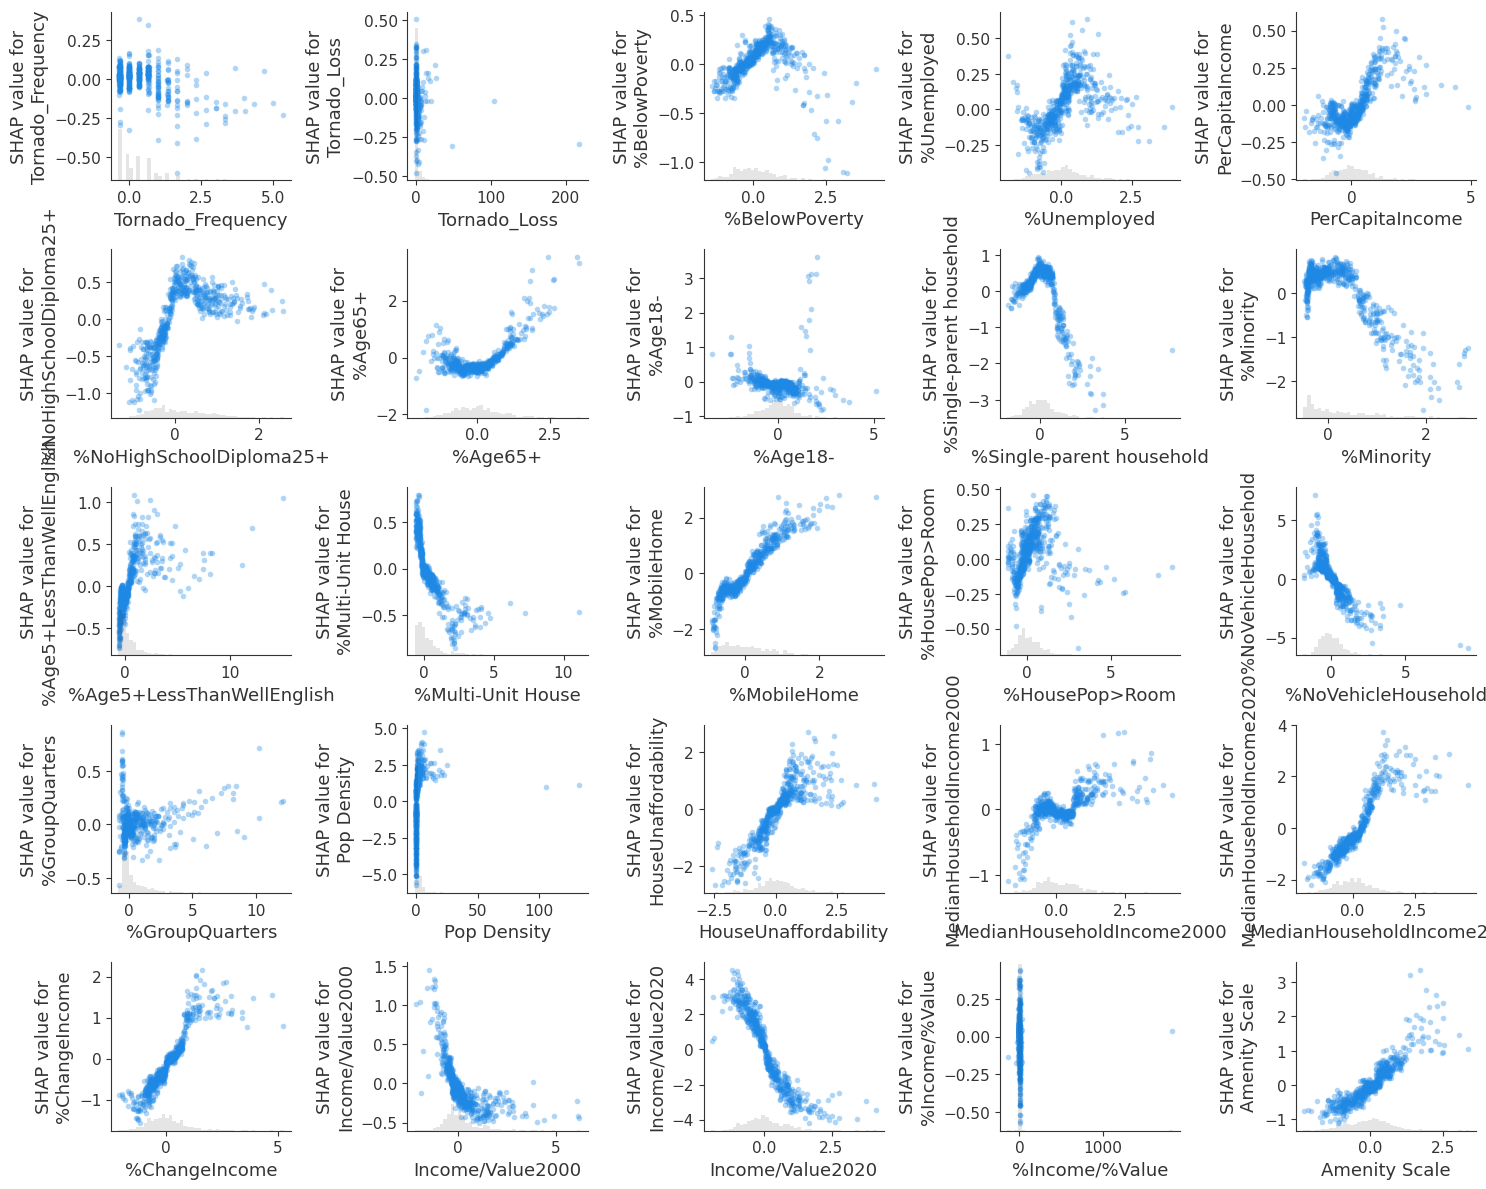

In [98]:
# Define all the features in your dataset
all_features = X_test.columns  # Replace with the features from your test set

# Set up the number of rows and columns for subplots
num_features = len(all_features)
cols = 5  # Number of columns in the subplot grid
rows = (num_features + cols - 1) // cols  # Calculate the number of rows needed

# Create the subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 12))

# Flatten axes for easy iteration
axes = axes.flatten()

# Generate SHAP dependence plots for each feature
for i, feature in enumerate(all_features):
    shap.plots.scatter(shap_values[:, feature],ax=axes[i], show=False, alpha=0.35)
#     sns.regplot(x=X_test[feature], y=shap_values[:, feature], ax=axes[i], scatter_kws={'s': 10}, line_kws={'color': 'red'})
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
#     shap.dependence_plot(
#         feature, shap_values.values, X_test, ax=axes[i], show=False
#     )
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
    

# Turn off unused subplots if the number of features is less than total subplots
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")
# plt.savefig(r'F:\LongMig2025\results\maps\xgboost\dependence.png', dpi=600, bbox_inches='tight')  # Specify the path and file name here

# Show the final figure
plt.tight_layout()
plt.show()


In [99]:
r2 = r2_score(y_test, y_pred)

# RMSE (Root Mean Squared Error)
rmse = mean_squared_error(y_test, y_pred, squared=False)

# ME (Mean Error, aka Bias)
me = (y_test - y_pred).mean()

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"Mean Error (ME): {me:.3f}")


R²: 0.670
RMSE: 5.269
Mean Error (ME): 0.599


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Remove Tornado Variables

Mean Squared Error: 27.122442097963873


 96%|=================== | 545/566 [00:24<00:00]       

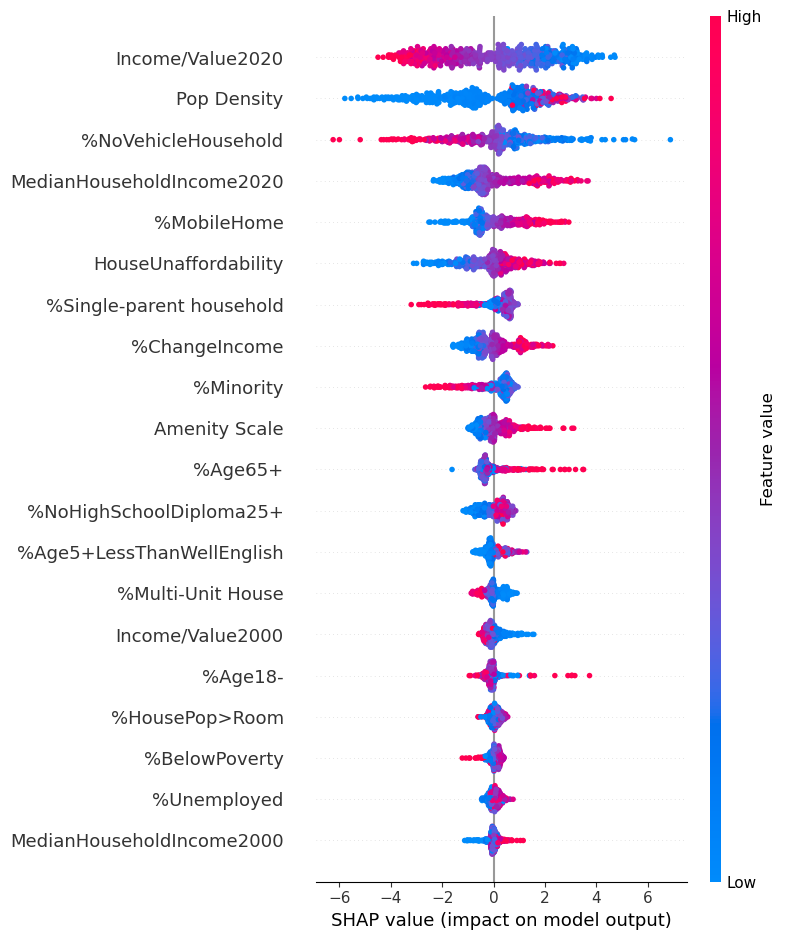

In [100]:
X = Tornado_Regression_data_used.drop(columns=['NMR', 'FIPS',
    "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss"
                                            ])
y = Tornado_Regression_data_used['NMR']

# # Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# # Train an XGBoost regression model
model = xgb.XGBRegressor(objective='reg:squarederror',
                             n_estimators=1000,  
    learning_rate=0.01,
    max_depth=6,  
    subsample=0.8,  
    colsample_bytree=0.8,
    reg_lambda=1,  
    reg_alpha=0,  
    missing=0)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Explain the model with SHAP
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Summary plot of feature importance
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
# plt.savefig(r'F:\LongMig2025\results\maps\xgboost\summary.png', dpi=600, bbox_inches='tight')
fig.clf()

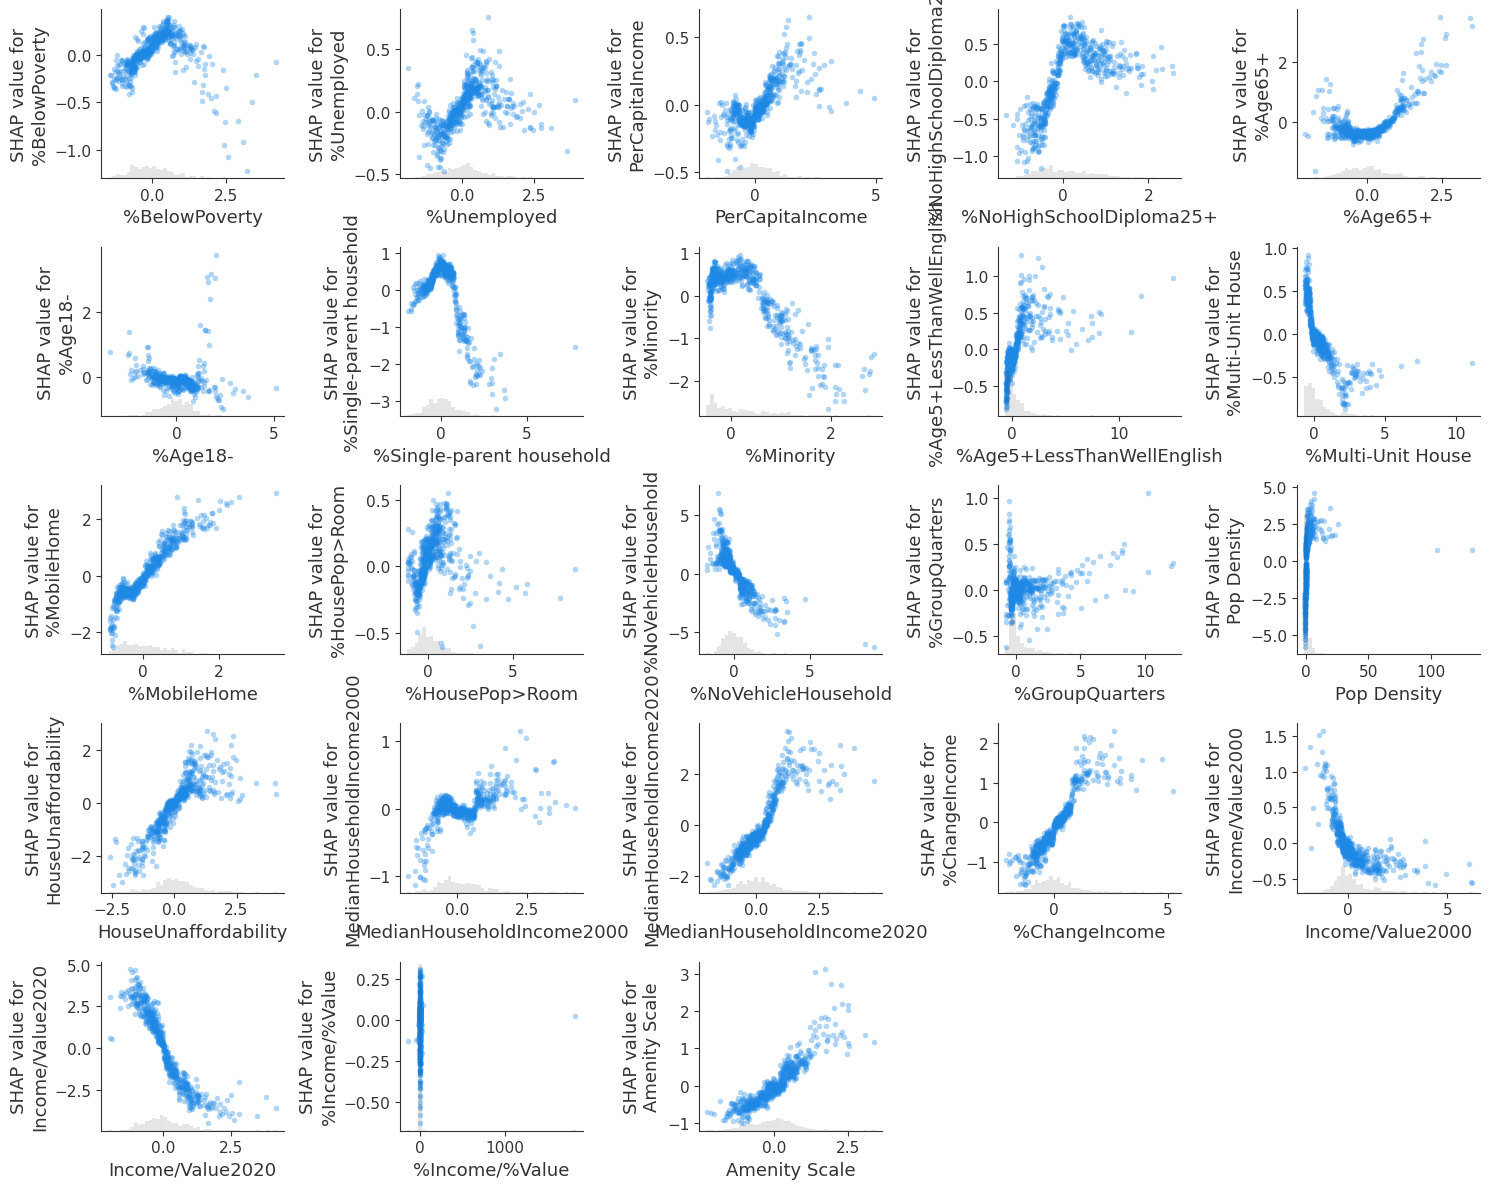

In [101]:
# Define all the features in your dataset
all_features = X_test.columns  # Replace with the features from your test set

# Set up the number of rows and columns for subplots
num_features = len(all_features)
cols = 5  # Number of columns in the subplot grid
rows = (num_features + cols - 1) // cols  # Calculate the number of rows needed

# Create the subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 12))

# Flatten axes for easy iteration
axes = axes.flatten()

# Generate SHAP dependence plots for each feature
for i, feature in enumerate(all_features):
    shap.plots.scatter(shap_values[:, feature],ax=axes[i], show=False, alpha=0.35)
#     sns.regplot(x=X_test[feature], y=shap_values[:, feature], ax=axes[i], scatter_kws={'s': 10}, line_kws={'color': 'red'})
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
#     shap.dependence_plot(
#         feature, shap_values.values, X_test, ax=axes[i], show=False
#     )
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
    

# Turn off unused subplots if the number of features is less than total subplots
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")
# plt.savefig(r'F:\LongMig2025\results\maps\xgboost\dependence.png', dpi=600, bbox_inches='tight')  # Specify the path and file name here

# Show the final figure
plt.tight_layout()
plt.show()


In [102]:
r2 = r2_score(y_test, y_pred)

# RMSE (Root Mean Squared Error)
rmse = mean_squared_error(y_test, y_pred, squared=False)

# ME (Mean Error, aka Bias)
me = (y_test - y_pred).mean()

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"Mean Error (ME): {me:.3f}")


R²: 0.677
RMSE: 5.208
Mean Error (ME): 0.591


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## VIF to exclude some factors

In [103]:
# Exclude specified columns
excluded_columns = ["NMR", "FIPS"]
df_vif = Flood_Regression_data_used.drop(columns=excluded_columns, errors="ignore")
# Recalculate VIF for remaining variables
vif_data_filtered = pd.DataFrame()
vif_data_filtered["Feature"] = df_vif.columns
vif_data_filtered["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]
vif_data_filtered.sort_values("VIF",ascending=False)

,Feature,VIF
25,MedianHouseholdIncome2020,57.744478
24,MedianHouseholdIncome2000,51.424736
26,%ChangeIncome,11.545414
10,PerCapitaIncome,7.426843
14,%Single-parent household,6.822986
15,%Minority,5.847162
8,%BelowPoverty,5.235233
27,Income/Value2000,4.556822
13,%Age18-,4.123385
11,%NoHighSchoolDiploma25+,3.980717


In [104]:
excluded_columns_flood = ["NMR", "FIPS","MedianHouseholdIncome2020","MedianHouseholdIncome2000",
                    "%ChangeIncome","PerCapitaIncome","%Single-parent household","%Minority",
                    "%BelowPoverty"]
df_vif = Flood_Regression_data_used.drop(columns=excluded_columns_flood, errors="ignore")
# Recalculate VIF for remaining variables
vif_data_filtered = pd.DataFrame()
vif_data_filtered["Feature"] = df_vif.columns
vif_data_filtered["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]

vif_data_filtered

,Feature,VIF
0,Flood_Frequency,1.111241
1,Flood_Loss,1.041494
2,Hurricane_Frequency,1.394344
3,Hurricane_Loss,1.084928
4,Wildfire_Frequency,1.308679
5,Wildfire_Loss,1.043017
6,Tornado_Frequency,1.298412
7,Tornado_Loss,1.044868
8,%Unemployed,1.814851
9,%NoHighSchoolDiploma25+,3.387507


In [105]:
# Exclude specified columns
excluded_columns = ["NMR", "FIPS"]
df_vif = Hurricane_Regression_data_used.drop(columns=excluded_columns, errors="ignore")
# Recalculate VIF for remaining variables
vif_data_filtered = pd.DataFrame()
vif_data_filtered["Feature"] = df_vif.columns
vif_data_filtered["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]
vif_data_filtered.sort_values("VIF",ascending=False)

,Feature,VIF
25,MedianHouseholdIncome2020,135.619435
24,MedianHouseholdIncome2000,102.263014
10,PerCapitaIncome,15.078194
26,%ChangeIncome,13.695387
14,%Single-parent household,9.668977
13,%Age18-,8.071498
8,%BelowPoverty,6.200959
17,%Multi-Unit House,4.863861
15,%Minority,4.842283
11,%NoHighSchoolDiploma25+,4.379681


In [106]:
excluded_columns_hurricane = ["NMR", "FIPS","MedianHouseholdIncome2020","MedianHouseholdIncome2000",
                    "%ChangeIncome","PerCapitaIncome","%Single-parent household","%Minority",
                    "%Age18-","%BelowPoverty"]
df_vif = Hurricane_Regression_data_used.drop(columns=excluded_columns_hurricane, errors="ignore")
# Recalculate VIF for remaining variables
vif_data_filtered = pd.DataFrame()
vif_data_filtered["Feature"] = df_vif.columns
vif_data_filtered["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]

vif_data_filtered

,Feature,VIF
0,Flood_Frequency,1.415865
1,Flood_Loss,1.059902
2,Hurricane_Frequency,1.253254
3,Hurricane_Loss,1.112264
4,Wildfire_Frequency,1.242184
5,Wildfire_Loss,1.023262
6,Tornado_Frequency,1.448323
7,Tornado_Loss,1.038078
8,%Unemployed,1.654762
9,%NoHighSchoolDiploma25+,3.566164


In [107]:
# Exclude specified columns
excluded_columns = ["NMR", "FIPS"]
df_vif = Wildfire_Regression_data_used.drop(columns=excluded_columns, errors="ignore")
# Recalculate VIF for remaining variables
vif_data_filtered = pd.DataFrame()
vif_data_filtered["Feature"] = df_vif.columns
vif_data_filtered["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]
vif_data_filtered.sort_values("VIF",ascending=False)

,Feature,VIF
25,MedianHouseholdIncome2020,36.222773
24,MedianHouseholdIncome2000,32.322510
26,%ChangeIncome,7.571927
27,Income/Value2000,7.367624
28,Income/Value2020,7.107189
10,PerCapitaIncome,6.308611
11,%NoHighSchoolDiploma25+,5.484297
15,%Minority,5.453285
16,%Age5+LessThanWellEnglish,5.241783
14,%Single-parent household,5.235401


In [108]:
excluded_columns_wildfire = ["NMR", "FIPS","MedianHouseholdIncome2020","MedianHouseholdIncome2000",
                    "%ChangeIncome","Income/Value2000","Income/Value2020",
                             "PerCapitaIncome","%NoHighSchoolDiploma25+","%Single-parent household","%Minority",
                    "%Age5+LessThanWellEnglish"]
df_vif = Hurricane_Regression_data_used.drop(columns=excluded_columns_wildfire, errors="ignore")
# Recalculate VIF for remaining variables
vif_data_filtered = pd.DataFrame()
vif_data_filtered["Feature"] = df_vif.columns
vif_data_filtered["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]

vif_data_filtered

,Feature,VIF
0,Flood_Frequency,1.418558
1,Flood_Loss,1.073605
2,Hurricane_Frequency,1.224544
3,Hurricane_Loss,1.091125
4,Wildfire_Frequency,1.239360
5,Wildfire_Loss,1.020367
6,Tornado_Frequency,1.476273
7,Tornado_Loss,1.038343
8,%BelowPoverty,3.631645
9,%Unemployed,1.810604


In [109]:
# Exclude specified columns
excluded_columns = ["NMR", "FIPS"]
df_vif = Tornado_Regression_data_used.drop(columns=excluded_columns, errors="ignore")
# Recalculate VIF for remaining variables
vif_data_filtered = pd.DataFrame()
vif_data_filtered["Feature"] = df_vif.columns
vif_data_filtered["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]
vif_data_filtered.sort_values("VIF",ascending=False)

,Feature,VIF
25,MedianHouseholdIncome2020,75.842266
24,MedianHouseholdIncome2000,62.396815
26,%ChangeIncome,15.546825
10,PerCapitaIncome,8.248104
14,%Single-parent household,7.850672
15,%Minority,5.785471
8,%BelowPoverty,5.658911
13,%Age18-,4.579959
27,Income/Value2000,4.444550
11,%NoHighSchoolDiploma25+,3.903905


In [110]:
excluded_columns_tornado = ["NMR", "FIPS","MedianHouseholdIncome2020","MedianHouseholdIncome2000",
                    "%ChangeIncome",
                             "PerCapitaIncome","%Single-parent household","%Minority",
                    "%BelowPoverty"]
df_vif = Hurricane_Regression_data_used.drop(columns=excluded_columns_tornado, errors="ignore")
# Recalculate VIF for remaining variables
vif_data_filtered = pd.DataFrame()
vif_data_filtered["Feature"] = df_vif.columns
vif_data_filtered["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]

vif_data_filtered

,Feature,VIF
0,Flood_Frequency,1.417319
1,Flood_Loss,1.083610
2,Hurricane_Frequency,1.257223
3,Hurricane_Loss,1.112265
4,Wildfire_Frequency,1.267842
5,Wildfire_Loss,1.023290
6,Tornado_Frequency,1.502134
7,Tornado_Loss,1.041403
8,%Unemployed,1.677204
9,%NoHighSchoolDiploma25+,3.575859


## Regression
## Regression for Flood

In [111]:
disaster_list =['NMR', 
#     "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss"
                                            ]
excluded_columns_flood_list = excluded_columns_flood+ disaster_list

In [112]:
Regression_data_used_ols = Flood_Regression_data_used

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=excluded_columns_flood_list)

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (All Variables)")
print(model_ols.summary())

r_squared = model_ols.rsquared
y_pred = model_ols.predict(X_ols)
rmse = np.sqrt(mean_squared_error(y, y_pred))
me = np.mean(y - y_pred)
print("R-squared:", r_squared)
print("RMSE:", rmse)
print("ME:", me)

OLS (All Variables)
                            OLS Regression Results                            
Dep. Variable:                    NMR   R-squared:                       0.405
Model:                            OLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                     104.3
Date:                Thu, 08 May 2025   Prob (F-statistic):          3.76e-294
Time:                        09:47:08   Log-Likelihood:                -9007.9
No. Observations:                2772   AIC:                         1.805e+04
Df Residuals:                    2753   BIC:                         1.817e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
co

## Regression for Hurricane

In [113]:
disaster_list =['NMR', 
    "Flood_Frequency","Flood_Loss",
#     "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss"
                                            ]
excluded_columns_hurricane_list = excluded_columns_hurricane+ disaster_list

In [114]:
Regression_data_used_ols = Hurricane_Regression_data_used

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=excluded_columns_hurricane_list)

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (All Variables)")
print(model_ols.summary())

r_squared = model_ols.rsquared
y_pred = model_ols.predict(X_ols)
rmse = np.sqrt(mean_squared_error(y, y_pred))
me = np.mean(y - y_pred)
print("R-squared:", r_squared)
print("RMSE:", rmse)
print("ME:", me)

OLS (All Variables)
                            OLS Regression Results                            
Dep. Variable:                    NMR   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.515
Method:                 Least Squares   F-statistic:                     45.93
Date:                Thu, 08 May 2025   Prob (F-statistic):          8.33e-102
Time:                        09:47:08   Log-Likelihood:                -2415.2
No. Observations:                 720   AIC:                             4866.
Df Residuals:                     702   BIC:                             4949.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
co

## Regression for Wildfire

In [115]:
disaster_list =['NMR', 
    "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
#     "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss"
                                            ]
excluded_columns_wildfire_list = excluded_columns_wildfire+ disaster_list

In [116]:
Regression_data_used_ols = Wildfire_Regression_data_used

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=excluded_columns_wildfire_list)

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (All Variables)")
print(model_ols.summary())

r_squared = model_ols.rsquared
y_pred = model_ols.predict(X_ols)
rmse = np.sqrt(mean_squared_error(y, y_pred))
me = np.mean(y - y_pred)
print("R-squared:", r_squared)
print("RMSE:", rmse)
print("ME:", me)

OLS (All Variables)
                            OLS Regression Results                            
Dep. Variable:                    NMR   R-squared:                       0.391
Model:                            OLS   Adj. R-squared:                  0.373
Method:                 Least Squares   F-statistic:                     22.65
Date:                Thu, 08 May 2025   Prob (F-statistic):           7.42e-48
Time:                        09:47:08   Log-Likelihood:                -1869.4
No. Observations:                 546   AIC:                             3771.
Df Residuals:                     530   BIC:                             3840.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const       

## Regression for Tornado

In [117]:
disaster_list =['NMR', 
    "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
#     "Tornado_Frequency","Tornado_Loss"
                                            ]
excluded_columns_tornado_list = excluded_columns_tornado+ disaster_list

In [118]:
Regression_data_used_ols = Tornado_Regression_data_used

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=excluded_columns_tornado_list)

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (All Variables)")
print(model_ols.summary())

r_squared = model_ols.rsquared
y_pred = model_ols.predict(X_ols)
rmse = np.sqrt(mean_squared_error(y, y_pred))
me = np.mean(y - y_pred)
print("R-squared:", r_squared)
print("RMSE:", rmse)
print("ME:", me)

OLS (All Variables)
                            OLS Regression Results                            
Dep. Variable:                    NMR   R-squared:                       0.465
Model:                            OLS   Adj. R-squared:                  0.461
Method:                 Least Squares   F-statistic:                     108.5
Date:                Thu, 08 May 2025   Prob (F-statistic):          8.51e-289
Time:                        09:47:08   Log-Likelihood:                -7328.3
No. Observations:                2264   AIC:                         1.469e+04
Df Residuals:                    2245   BIC:                         1.480e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
co